# **AI-Driven BCMA Binder Design and Validation via ProteinMPNN and OpenMM**

---

## Introduction
This project demonstrates an AI-driven molecular design and validation workflow for optimizing BCMA binders. The goal is to identify novel peptide sequences that can bind effectively and stably to the BCMA protein, which is a key target in multiple myeloma therapy. This notebook provides a step-by-step guide through the computational pipeline, from initial protein structure preparation to the final validation of designed binder candidates using molecular dynamics simulations.

## Scope and Limitations
This workflow focuses on early-stage binder evaluation—energy and stability screening—rather than exhaustive
simulation or experimental calibration. Long-timescale MD (microseconds) and explicit solvent simulations are
excluded to maintain runtime efficiency within the Kaggle GPU environment.
Predictions are **comparative** within the generated candidate set, not absolute binding free energies. The computational screens provide a prioritized list of candidates that would require experimental validation to confirm binding affinity and efficacy.

## Model Modules & Implementation

### 1. Design & Screening (NB1)
- **Structural Input & Pre-Processing:** The workflow starts by obtaining the 3D structure of the BCMA protein, either from the AlphaFold database or a user-provided PDB/mmCIF file. PDBFixer and OpenMM are used to clean and minimize the structure. The crystal structure of BCMA bound to its natural ligand APRIL (PDB 1XU2) is downloaded to identify the binding interface and extract a mini-binder seed backbone.
- **Redesign & Sequence Optimization:** ProteinMPNN is employed to generate a diverse set of novel amino acid sequences (designs) threaded onto the extracted mini-binder backbone structure.
- **Developability Triage:** Simple sequence-based metrics (charge, hydropathy, glycosylation motifs, cysteine count) are calculated to filter out sequences with undesirable developability characteristics.
- **ΔE Screening:** OpenMM is used to minimize the energy of the receptor (BCMA), the binder candidate, and the complex formed by the two. The binding energy proxy (ΔE) is calculated as the energy of the complex minus the sum of the energies of the unbound receptor and binder (ΔE = E_complex − (E_receptor + E_binder)). More negative ΔE values suggest more favorable binding.

### 2. Validation & Stability (NB2)
- **Candidate Staging:** The top candidates based on ΔE and developability filters are staged for further analysis.
- **Light MD Simulation:** A short molecular dynamics simulation in implicit solvent (OBC2 or GBN2) is performed on the best candidate complex to assess its structural stability and dynamic behavior at the interface.
- **Structural Analysis:** MDTraj is used to calculate the Root Mean Square Deviation (RMSD) of the complex over time, providing a measure of its stability relative to the starting structure. Interface contacts (heavy-atom pairs within a cutoff) are also analyzed to monitor the integrity of the binding interaction during the simulation. A sequence report summarizes the properties of the chains in the simulated complex.


## Key Results and Interpretation
The ProteinMPNN design phase successfully generated a diverse set of mini-binder sequences. Initial developability screening filtered candidates based on predicted physical properties. The subsequent ΔE screening, utilizing OpenMM minimization, identified several low-energy binder designs. The **most favorable candidate**, based on the lowest (most negative) ΔE value, was selected for further validation.

The short molecular dynamics simulation of the top-ranked binder-BCMA complex showed a relatively low and stable RMSD over the simulation time, indicating that the designed binder maintains a consistent structure and pose when bound to BCMA. Analysis of interface contacts throughout the simulation confirmed that key interactions between the binder and receptor are largely preserved.

These results suggest that the top-ranked designed binder is predicted to form a stable complex with BCMA at the specified binding interface. While ΔE and short MD are proxies and not direct measures of binding affinity, these computational screenings provide strong evidence that this candidate is promising for further investigation, including longer explicit solvent MD simulations, more rigorous docking studies (like Smina or DiffDock), and ultimately, experimental validation.



## Summary
This report details an AI-accelerated workflow for BCMA binder design and validation. The pipeline integrates ProteinMPNN for sequence design, OpenMM for energy minimization and short MD simulations, and Biopython/MDTraj for structural analysis. Key outputs include a list of designed sequences, ΔE values as a binding energy proxy, and MD-based metrics (RMSD, contacts) for assessing complex stability.







# **Workflow Diagram**



                ┌────────────────────────────────────────┐
                │         Phase 1 – Target Prep          │
                │  • AlphaFold/ESMFold BCMA structure    │
                │  • PDBFixer repair + OpenMM relaxation │
                └────────────────────────────────────────┘
                                   │
                                   ▼
                ┌────────────────────────────────────────┐
                │        Phase 2 – Complex Context       │
                │  • 1XU2 APRIL–BCMA complex download    │
                │  • Interface mapping (≤ 5 Å contacts)  │
                │  • Mini-binder seed extraction (~21 aa)│
                └────────────────────────────────────────┘
                                   │
                                   ▼
                ┌────────────────────────────────────────┐
                │     Phase 3 – Redesign (ProteinMPNN)   │
                │  • Redesign APRIL mini-binder backbone │
                │  • Generate 32-64 sequence variants    │
                │  • Optional ESMFold refold check       │
                └────────────────────────────────────────┘
                                   │
                                   ▼
                ┌────────────────────────────────────────┐
                │      Phase 4 – Docking & Screening     │
                │  • TorchMD-Net **ΔE** (Binding Energy Diff)│
                │  • OpenMM short MD (RMSD Stability)    │
                │  • *Smina/DiffDock (Planned)* │
                └────────────────────────────────────────┘
                                   │
                                   ▼
                ┌────────────────────────────────────────┐
                │  Phase 5 – Physicochemical Triage (Actual) │
                │  • BioPython (Charge/GRAVY)            │
                │  • Regex Scan (Glycosylation/Cysteine) │
                │  • *AggScore/BLAST (Planned)* │
                └────────────────────────────────────────┘
                                   │
                                   ▼
                ┌────────────────────────────────────────┐
                │     Phase 6 – Ranking & Selection      │
                │  • Integrated score table (ΔE, RMSD, PhysChem)│
                │  • Select top 3 mini-binders for bench │
                └────────────────────────────────────────┘
```

# **PART I.**

# **0) Runtime & Paths**

In [1]:
import os, sys, platform, pathlib

assert os.path.exists('/kaggle/working'), "This notebook is intended for Kaggle only."
print("Python:", platform.python_version())
print("Executable:", sys.executable)
print("OS:", platform.platform())

WORKDIR = pathlib.Path('/kaggle/working').resolve()
INPUTDIR = pathlib.Path('/kaggle/input').resolve()
OUTDIR = WORKDIR / 'bcma_outputs'
OUTDIR.mkdir(exist_ok=True)
print("WORKDIR:", WORKDIR)
print("INPUTDIR:", INPUTDIR)
print("OUTDIR:", OUTDIR)


Python: 3.11.13
Executable: /usr/bin/python3
OS: Linux-6.6.56+-x86_64-with-glibc2.35
WORKDIR: /kaggle/working
INPUTDIR: /kaggle/input
OUTDIR: /kaggle/working/bcma_outputs


# **1) Install Cells**

# A) Core scientific wheels

In [2]:
# Step A: Core stack
import sys, subprocess
subprocess.run(f"{sys.executable} -m pip install -q biopython openmm torchmd-net", shell=True, check=True)
print("✅ biopython, openmm, torchmd-net installed")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
libcugraph-cu12 25.6.0 requires libraft-cu12==25.6.*, but you have libraft-cu12 25.2.0 which is incompatible.
pylibcugraph-cu12 25.6.0 requires pylibraft-cu12==25.6.*, but you have pylibraft-cu12 25.2.0 which is incompatible.
pylibcugraph-cu12 25.6.0 requires rmm-cu12==25.6.*, but you have rmm-cu12 25.2.0 which is incompatible.


✅ biopython, openmm, torchmd-net installed


# B) ESM + ProteinMPNN

In [3]:
# Step B: ESM + ProteinMPNN
import sys, subprocess
subprocess.run(f"{sys.executable} -m pip install -q fair-esm proteinmpnn", shell=True, check=True)
print("✅ fair-esm, proteinmpnn installed")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 MB 18.5 MB/s eta 0:00:00
✅ fair-esm, proteinmpnn installed


# C) PDB Fixer from GitHub (robust)

In [4]:
# Step C: PDBFixer (not on PyPI) — try common refs, then default branch
import sys, subprocess

refs = ["master", "main", "1.11", "1.10", "1.9"]
installed = False
for ref in refs:
    print(f"Attempting pdbfixer ref: {ref}")
    r = subprocess.run(
        f'{sys.executable} -m pip install -q --no-deps --no-build-isolation git+https://github.com/openmm/pdbfixer.git@{ref}',
        shell=True
    )
    if r.returncode == 0:
        print(f"✅ pdbfixer installed from ref: {ref}")
        installed = True
        break
    else:
        print(f"⚠️  ref {ref} failed; trying next…")

if not installed:
    r = subprocess.run(
        f'{sys.executable} -m pip install -q --no-deps --no-build-isolation git+https://github.com/openmm/pdbfixer.git',
        shell=True, check=True
    )
    print("✅ pdbfixer installed from default branch")


Attempting pdbfixer ref: master
✅ pdbfixer installed from ref: master


# D) Sanity check versions

In [5]:
import importlib, importlib.metadata as im

def ver(name):
    try:
        return im.version(name)
    except Exception:
        try:
            mod = importlib.import_module(name)
            return getattr(mod, "__version__", "unknown")
        except Exception:
            return "not installed"

print("biopython  :", ver("biopython"))
print("openmm     :", ver("openmm"))
print("torchmd-net:", ver("torchmd-net"))
print("fair-esm   :", ver("fair-esm"))
print("proteinmpnn:", ver("proteinmpnn"))
try:
    import pdbfixer
    print("pdbfixer   :", getattr(pdbfixer, "__version__", "unknown"))
except Exception as e:
    print("pdbfixer   : import error →", e)


biopython  : 1.86
openmm     : 8.4.0
torchmd-net: 2.4.10
fair-esm   : 2.0.0
proteinmpnn: 0.1.3
pdbfixer   : unknown


# **2) Config (simple, explicit)**

In [6]:
# Initialize configuration holder
class Config:
    pass

CFG = Config()

# Default inputs
CFG.PDB_INPUT_PATH = "/kaggle/input/bcma-full-fasta/bcma_full.fasta.txt"  # If a PDB uploaded, set its absolute path here
CFG.FASTA_STRING = ""  # If needed to fold from sequence (ESMFold path is disabled by default)
CFG.DO_ESMFOLD = False  # We default to AFDB fallback to avoid openfold dependency hassles

# AlphaFold fallback configuration (our default path)
CFG.USE_ALPHAFOLD = True  # Enable AFDB fallback
CFG.UNIPROT_ID = "Q02223"  # BCMA / TNFRSF17
CFG.ECD_RANGE = None  # None => full-length; set to (start, end) to slice ECD only

# ProteinMPNN prep
CFG.PREPARE_PROTEINMPNN_INPUT = True
CFG.MPNN_NUM_SAMPLES = 32

print("✅ CFG object initialized.")


✅ CFG object initialized.


In [7]:
import importlib, pkgutil

def version_of(pkg_name):
    try:
        # Try distribution metadata
        import importlib.metadata as im
        return im.version(pkg_name)
    except Exception:
        pass
    try:
        # Fall back to module attribute
        mod = importlib.import_module(pkg_name)
        return getattr(mod, "__version__", "unknown")
    except Exception:
        return "unknown"

print("biopython:", version_of("biopython"))
print("openmm:", version_of("openmm"))
print("pdbfixer:", version_of("pdbfixer"))
print("fair-esm:", version_of("fair-esm"))
print("proteinmpnn:", version_of("proteinmpnn"))


biopython: 1.86
openmm: 8.4.0
pdbfixer: 1.12.0
fair-esm: 2.0.0
proteinmpnn: 0.1.3


# **3) FASTA Loader (from the dataset path)**


In [8]:
from pathlib import Path

# Update this path if your dataset name or filename changes
FASTA_PATH = Path("/kaggle/input/bcma-full-fasta/bcma_full.fasta.txt")

if FASTA_PATH.exists():
    def read_fasta_text(path: Path) -> str:
        txt = path.read_text().strip()
        lines = [l.strip() for l in txt.splitlines() if l.strip()]
        assert lines and lines[0].startswith(">"), "FASTA must start with a header '>'"
        seq = "".join([l for l in lines[1:] if not l.startswith(">")]).upper()
        valid = set("ACDEFGHIKLMNPQRSTVWY")
        bad = [c for c in seq if c not in valid]
        assert not bad, f"Invalid letters found in sequence: {set(bad)}"
        print(f"Sequence length: {len(seq)} aa")
        return txt

    CFG.FASTA_STRING = read_fasta_text(FASTA_PATH)
    # We *can* set DO_ESMFOLD=True, but ESMFold requires openfold deps; we keep it False by default.
    CFG.DO_ESMFOLD = False
    CFG.PDB_INPUT_PATH = ""
    print(f"✅ FASTA loaded from: {FASTA_PATH}")
else:
    print("⚠️ FASTA file not found; proceeding with AFDB model by UniProt ID.")


Sequence length: 207 aa
✅ FASTA loaded from: /kaggle/input/bcma-full-fasta/bcma_full.fasta.txt


# 3.A) Config overrides (full-length, AlphaFold fallback)

In [9]:
# Initialize configuration holder if not defined
class Config:
    pass

CFG = Config()

# Default attributes so later cells won't error
CFG.PDB_INPUT_PATH = ""
CFG.FASTA_STRING = ""
CFG.DO_ESMFOLD = False
CFG.USE_ALPHAFOLD = True
CFG.UNIPROT_ID = "Q02223"
CFG.ECD_RANGE = None

print("✅ CFG object initialized.")


✅ CFG object initialized.


In [10]:
# Use AlphaFold DB full-length BCMA (TNFRSF17 / Q02223)
CFG.USE_ALPHAFOLD = True
CFG.UNIPROT_ID = "Q02223"
CFG.ECD_RANGE = None        # <-- Full length (no slicing)
CFG.DO_ESMFOLD = False      # Skip ESMFold for this run
CFG.PDB_INPUT_PATH = ""     # Ensure we don't use a local PDB
print("Config set for AlphaFold full-length BCMA:", CFG.UNIPROT_ID)


Config set for AlphaFold full-length BCMA: Q02223


# 3.B) Helpers: download AlphaFold model (keeps existing imports)

In [11]:
# Install Biopython (provides Bio.PDB)
!pip install -q biopython

# Sanity check
import Bio
print("✅ Biopython installed:", Bio.__version__)


✅ Biopython installed: 1.86


In [12]:
import pathlib, urllib.request, json, io, sys
from urllib.error import HTTPError, URLError

# Biopython may not be needed immediately, but we keep these imports where they were used before
from Bio.PDB import PDBParser, PDBIO, Select

def _http_get(url: str, timeout=60):
    req = urllib.request.Request(url, headers={"User-Agent": "kaggle-bcma-workflow"})
    with urllib.request.urlopen(req, timeout=timeout) as resp:
        return resp.read()

def download_alphafold_pdb(uniprot_id: str, out_dir: pathlib.Path) -> pathlib.Path:
    """
    Query AFDB API for the prediction record and download the provided structure URL.
    Falls back to known filename patterns if API is unavailable.
    Returns local path to a .pdb or .cif file.
    """
    out_dir.mkdir(parents=True, exist_ok=True)
    uid = uniprot_id.strip().upper()

    # 1) Try AFDB API to get the actual URL
    api_url = f"https://alphafold.ebi.ac.uk/api/prediction/{uid}"
    structure_url = None
    try:
        print(f"Querying AFDB API: {api_url}")
        data = json.loads(_http_get(api_url).decode("utf-8"))
        # API returns a list of predictions for the ID; pick the first
        if isinstance(data, list) and data:
            rec = data[0]
            # Keys observed historically: 'pdbUrl' (PDB) and 'cifUrl' (mmCIF)
            structure_url = rec.get("pdbUrl") or rec.get("cifUrl")
            if not structure_url and "structures" in rec and rec["structures"]:
                # Some variants have nested structure info
                s0 = rec["structures"][0]
                structure_url = s0.get("pdbUrl") or s0.get("cifUrl")
        if structure_url:
            print("AFDB provided structure URL:", structure_url)
        else:
            print("AFDB API responded but no structure URL found; will try filename patterns.")
    except Exception as e:
        print("AFDB API lookup failed:", e)
        print("Falling back to filename patterns…")

    # 2) If we have a URL from the API, try to download PDB/mmCIF
    if structure_url:
        ext = ".pdb" if structure_url.lower().endswith(".pdb") else ".cif"
        out_path = out_dir / f"AF-{uid}{ext}"
        try:
            print(f"Downloading {ext.upper()} from {structure_url} …")
            urllib.request.urlretrieve(structure_url, out_path)
            if out_path.exists() and out_path.stat().st_size > 0:
                print("Downloaded:", out_path)
                return out_path
        except Exception as e:
            print("Download via API URL failed:", e)

    # 3) Fallbacks to common filename patterns (v4/v2, PDB or CIF)
    candidates = [
        f"https://alphafold.ebi.ac.uk/files/AF-{uid}-F1-model_v4.pdb",
        f"https://alphafold.ebi.ac.uk/files/AF-{uid}-F1-model_v4.cif",
        f"https://alphafold.ebi.ac.uk/files/AF-{uid}-F1-model_v2.pdb",
        f"https://alphafold.ebi.ac.uk/files/AF-{uid}-F1-model_v2.cif",
    ]
    last_err = None
    for url in candidates:
        try:
            ext = ".pdb" if url.lower().endswith(".pdb") else ".cif"
            out_path = out_dir / f"AF-{uid}{ext}"
            print(f"Trying: {url}")
            urllib.request.urlretrieve(url, out_path)
            if out_path.exists() and out_path.stat().st_size > 0:
                print("Downloaded:", out_path)
                return out_path
        except Exception as e:
            print("  attempt failed:", e)
            last_err = e

    raise FileNotFoundError(f"Could not fetch AlphaFold structure for {uid}. Last error: {last_err}")


# 3.C) Phase-1 (revised) — AlphaFold → PDBFixer → OpenMM (full length)

In [13]:
# Global output directory for all BCMA stages
import pathlib

OUTDIR = pathlib.Path("/kaggle/working/bcma_outputs")
OUTDIR.mkdir(exist_ok=True)

print("✅ OUTDIR initialized:", OUTDIR.resolve())


✅ OUTDIR initialized: /kaggle/working/bcma_outputs


# **4) Helpers — AFDB downloader, repair, minimize**

In [14]:
# 4) Helpers — AFDB downloader (API-first), flexible PDB/mmCIF repair, OpenMM minimize
import pathlib, urllib.request, json

def download_alphafold_struct(uniprot_id: str, out_dir: pathlib.Path) -> pathlib.Path:
    """
    Try AlphaFold DB API first, then fallback to static file URLs.
    Returns the downloaded structure path (PDB or mmCIF).
    """
    out_dir.mkdir(exist_ok=True)
    uid = uniprot_id.strip().upper()

    # --- 1) Try API lookup ---
    try:
        api_url = f"https://alphafold.ebi.ac.uk/api/prediction/{uid}"
        print(f"Querying AFDB API: {api_url}")
        with urllib.request.urlopen(api_url) as resp:
            data = json.loads(resp.read())
        if isinstance(data, list) and len(data) > 0:
            pdb_url = data[0].get("pdbUrl") or data[0].get("cifUrl")
            if pdb_url:
                out_path = out_dir / f"AF-{uid}.pdb"
                print(f"Downloading AlphaFold model from {pdb_url} …")
                urllib.request.urlretrieve(pdb_url, out_path)
                print("Downloaded:", out_path)
                return out_path
    except Exception as e:
        print("AFDB API lookup failed:", e)
        print("Falling back to filename patterns…")

    # --- 2) Fallback patterns ---
    candidates = [
        f"https://alphafold.ebi.ac.uk/files/AF-{uid}-F1-model_v4.pdb",
        f"https://alphafold.ebi.ac.uk/files/AF-{uid}-F1-model_v4.cif",
        f"https://alphafold.ebi.ac.uk/files/AF-{uid}-F1-model_v2.pdb",
        f"https://alphafold.ebi.ac.uk/files/AF-{uid}-F1-model_v2.cif",
    ]
    last_err = None
    for url in candidates:
        try:
            ext = ".pdb" if url.lower().endswith(".pdb") else ".cif"
            out_path = out_dir / f"AF-{uid}{ext}"
            print(f"Trying: {url}")
            urllib.request.urlretrieve(url, out_path)
            if out_path.exists() and out_path.stat().st_size > 0:
                print("Downloaded:", out_path)
                return out_path
        except Exception as e:
            print("  attempt failed:", e)
            last_err = e

    raise FileNotFoundError(f"Could not fetch AlphaFold structure for {uid}. Last error: {last_err}")


# --- Flexible repair: accepts PDB or mmCIF input, outputs PDB ---
def repair_with_pdbfixer(struct_in: pathlib.Path, pdb_out: pathlib.Path, ph=7.0) -> pathlib.Path:
    from pdbfixer import PDBFixer
    from openmm.app import PDBFile
    fixer = PDBFixer(filename=str(struct_in))
    fixer.findMissingResidues()
    fixer.findMissingAtoms()
    fixer.addMissingAtoms()
    fixer.addMissingHydrogens(pH=ph)
    with open(pdb_out, "w") as f:
        PDBFile.writeFile(fixer.topology, fixer.positions, f)
    return pdb_out


# --- OpenMM minimize (GPU if available; else CPU) ---
def openmm_minimize(pdb_path: pathlib.Path, out_dir: pathlib.Path, tag: str = "bcma") -> pathlib.Path:
    from openmm.app import PDBFile, Modeller, ForceField, Simulation, HBonds, NoCutoff
    from openmm import unit, LangevinIntegrator, Platform

    out_dir.mkdir(exist_ok=True)
    pdb = PDBFile(str(pdb_path))
    ff = ForceField("amber14-all.xml", "amber14/tip3pfb.xml")
    modeller = Modeller(pdb.topology, pdb.positions)
    system = ff.createSystem(modeller.topology, nonbondedMethod=NoCutoff, constraints=HBonds)
    integrator = LangevinIntegrator(300 * unit.kelvin, 1.0 / unit.picosecond, 0.002 * unit.picoseconds)

    try:
        platform = Platform.getPlatformByName("CUDA")
    except Exception:
        try:
            platform = Platform.getPlatformByName("OpenCL")
        except Exception:
            platform = Platform.getPlatformByName("CPU")

    sim = Simulation(modeller.topology, system, integrator, platform)
    sim.context.setPositions(modeller.positions)
    print("Minimizing energy (500 iters)…")
    sim.minimizeEnergy(maxIterations=500)
    state = sim.context.getState(getEnergy=True, getPositions=True)
    energy = state.getPotentialEnergy()
    out_pdb = out_dir / f"{tag}_minimized.pdb"
    with open(out_pdb, "w") as f:
        PDBFile.writeFile(sim.topology, state.getPositions(), f)
    print(f"✅ Minimization done. Energy: {energy}")
    print(f"Saved minimized PDB → {out_pdb}")
    return out_pdb


# **5) Phase‑1 — AlphaFold full‑length**

In [15]:
# Phase-1 — get structure (PDB/mmCIF), repair with PDBFixer, minimize with OpenMM

from pathlib import Path

fold_dir = OUTDIR / "fold"
prep_dir = OUTDIR / "prep"
min_dir  = OUTDIR / "minimized"
for d in (fold_dir, prep_dir, min_dir):
    d.mkdir(parents=True, exist_ok=True)

pdb_source = None
tag = "bcma"

# 1) If a valid PDB/mmCIF path was provided, use it (ignore FASTA files here)
user_path = Path(CFG.PDB_INPUT_PATH) if getattr(CFG, "PDB_INPUT_PATH", "") else None
if user_path and user_path.exists() and user_path.suffix.lower() in {".pdb", ".cif"}:
    print("Using provided structure:", user_path)
    pdb_source = user_path
    tag = "user_pdb"
else:
    if user_path and user_path.exists():
        print(f"Note: Provided path is not a PDB/mmCIF (suffix={user_path.suffix}). "
              "Ignoring and using AlphaFold instead.")

# 2) AlphaFold fallback (full-length BCMA)
if pdb_source is None and getattr(CFG, "USE_ALPHAFOLD", True):
    af_dir = fold_dir / "alphafold"
    pdb_source = download_alphafold_struct(CFG.UNIPROT_ID, af_dir)  # may be .pdb or .cif
    tag = f"AF_{CFG.UNIPROT_ID}"
    print("Using AlphaFold model:", pdb_source)

# 3) Safety check
assert pdb_source is not None and Path(pdb_source).exists(), "No structure source could be prepared."

# 4) PDBFixer repair -> always write PDB
fixed_pdb = prep_dir / f"{tag}_fixed.pdb"
print("Repairing structure with PDBFixer …")
fixed_path = repair_with_pdbfixer(Path(pdb_source), fixed_pdb, ph=7.0)
print("Fixed PDB:", fixed_path)

# 5) OpenMM minimization
minimized_pdb = openmm_minimize(fixed_path, min_dir, tag=tag)
print("Minimized PDB:", minimized_pdb)


Querying AFDB API: https://alphafold.ebi.ac.uk/api/prediction/Q02223
Downloaded: /kaggle/working/bcma_outputs/fold/alphafold/AF-Q02223.pdb
Using AlphaFold model: /kaggle/working/bcma_outputs/fold/alphafold/AF-Q02223.pdb
Repairing structure with PDBFixer …
Fixed PDB: /kaggle/working/bcma_outputs/prep/AF_Q02223_fixed.pdb
Minimizing energy (500 iters)…
✅ Minimization done. Energy: -7683.979835510254 kJ/mol
Saved minimized PDB → /kaggle/working/bcma_outputs/minimized/AF_Q02223_minimized.pdb
Minimized PDB: /kaggle/working/bcma_outputs/minimized/AF_Q02223_minimized.pdb


# 3D Visualization

In [16]:
# Quick 3D view (optional)
import sys, subprocess
subprocess.run(f"{sys.executable} -m pip install -q py3Dmol", shell=True, check=False)

import py3Dmol
with open(str(minimized_pdb), "r") as f:
    pdb_str = f.read()
view = py3Dmol.view(width=640, height=480)
view.addModel(pdb_str, "pdb")
view.setStyle({"cartoon": {"color": "spectrum"}})
view.zoomTo()
view.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Phase-2: ProteinMPNN

# Phase 2A — Prep backbone + metadata

In [17]:
# Copy minimized structure into a ProteinMPNN-friendly location and write metadata
import json, shutil, pathlib

mpnn_root = OUTDIR / 'proteinmpnn'
backbone_dir = mpnn_root / 'backbones'
design_out  = mpnn_root / 'designs'
backbone_dir.mkdir(parents=True, exist_ok=True)
design_out.mkdir(parents=True, exist_ok=True)

# minimized_pdb comes from Phase-1; ensure it exists
min_path = pathlib.Path(minimized_pdb)
assert min_path.exists(), f"Minimized PDB not found: {min_path}"

bb_pdb = backbone_dir / min_path.name
if bb_pdb.resolve() != min_path.resolve():
    shutil.copy2(min_path, bb_pdb)

meta = {
    "backbone": str(bb_pdb),
    "uniprot_id": getattr(CFG, "UNIPROT_ID", "NA"),
    "source": "AlphaFold DB (full-length) → PDBFixer → OpenMM",
    "notes": "Ready for ProteinMPNN design",
    "num_seq_per_target": getattr(CFG, "MPNN_NUM_SAMPLES", 32),
}
with open(mpnn_root / "proteinmpnn_input.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Backbone prepared:", bb_pdb)
print("Metadata:", mpnn_root / "proteinmpnn_input.json")


Backbone prepared: /kaggle/working/bcma_outputs/proteinmpnn/backbones/AF_Q02223_minimized.pdb
Metadata: /kaggle/working/bcma_outputs/proteinmpnn/proteinmpnn_input.json


# Phase 2B — ProteinMPNN setup (repo + weights discovery)

In [18]:
import os, subprocess, sys, pathlib, glob

# Clone repo (idempotent)
repo_dir = pathlib.Path("/kaggle/working/proteinmpnn_repo")
if not repo_dir.exists():
    print("Cloning ProteinMPNN …")
    subprocess.run("git clone https://github.com/dauparas/ProteinMPNN.git /kaggle/working/proteinmpnn_repo", shell=True, check=True)
else:
    print("ProteinMPNN repo already present.")

# Try to locate pretrained weights in a Kaggle dataset named 'proteinmpnn-weights'
weights_dir = pathlib.Path("/kaggle/input/proteinmpnn-weights")
found_weights = None
if weights_dir.exists():
    candidates = list(weights_dir.glob("*.pt"))
    if candidates:
        found_weights = str(candidates[0])
        print("Found weights:", found_weights)
    else:
        print("No *.pt files in /kaggle/input/proteinmpnn-weights")
else:
    print("Dataset '/kaggle/input/proteinmpnn-weights' not found (you can upload weights there).")

# If a direct URL to weights is available, it can be uncommented and set here:
# WEIGHTS_URL = "<PUT_PUBLIC_URL_TO_PT_FILE>"
# if WEIGHTS_URL:
#     dest = "/kaggle/working/proteinmpnn_weights.pt"
#     subprocess.run(f"wget -O {dest} '{WEIGHTS_URL}'", shell=True, check=True)
#     found_weights = dest

if not found_weights:
    print("\n⚠️  No weights found yet. You can either:")
    print("   • Upload a Kaggle dataset named 'proteinmpnn-weights' containing a .pt file, or")
    print("   • Provide a direct URL in WEIGHTS_URL above and uncomment the wget block.")
else:
    print("✅ Weights ready:", found_weights)


Cloning ProteinMPNN …


Cloning into '/kaggle/working/proteinmpnn_repo'...


Dataset '/kaggle/input/proteinmpnn-weights' not found (you can upload weights there).

⚠️  No weights found yet. You can either:
   • Upload a Kaggle dataset named 'proteinmpnn-weights' containing a .pt file, or
   • Provide a direct URL in WEIGHTS_URL above and uncomment the wget block.


# (auto-detect weights and run design)

In [19]:
import pathlib, os, subprocess, sys, glob, json

repo_dir = pathlib.Path("/kaggle/working/proteinmpnn_repo")
assert repo_dir.exists(), "ProteinMPNN repo missing. Re-run the clone cell."

# Prefer vanilla weights (general). Fallback to soluble if desired.
CANDIDATE_DIRS = [
    repo_dir / "vanilla_model_weights",
    repo_dir / "soluble_model_weights",
    repo_dir / "ca_model_weights",  # for plan CA-only designs
]

weights_dir = None
model_name  = None  # v_48_020 is a solid default when present

for d in CANDIDATE_DIRS:
    pts = list(d.glob("*.pt"))
    if pts:
        weights_dir = d
        # Pick a reasonable default name from files present
        names = [p.stem for p in pts]
        # prefer v_48_020 if available, else first
        pref = [n for n in names if "v_48_020" in n] or names
        model_name = pref[0]
        break

if weights_dir is None:
    print("⚠️ Could not find .pt files inside the cloned repo:")
    for d in CANDIDATE_DIRS:
        print("  -", d)
    print("\nOptions:")
    print("  1) Upload a Kaggle dataset with a .pt file (e.g., '/kaggle/input/proteinmpnn-weights/*.pt'), or")
    print("  2) Provide a direct URL and use wget to download into /kaggle/working.")
    raise SystemExit("No local weights found in repo; please choose one of the options above.")

print("✅ Using weights directory:", weights_dir)
print("✅ Model name:", model_name)

# Build CLI
BB_PDB = str((pathlib.Path('/kaggle/working/bcma_outputs/proteinmpnn/backbones') / pathlib.Path(str(globals().get('minimized_pdb'))).name))
OUT_DIR = "/kaggle/working/bcma_outputs/proteinmpnn/designs"
os.makedirs(OUT_DIR, exist_ok=True)

cmd = (
    f"python {repo_dir}/protein_mpnn_run.py "
    f"--pdb_path {BB_PDB} "
    f"--out_folder {OUT_DIR} "
    f"--num_seq_per_target {getattr(globals().get('CFG', object()), 'MPNN_NUM_SAMPLES', 32)} "
    f"--seed 42 "
    f"--path_to_model_weights {weights_dir} "
    f"--model_name {model_name}"
)
print("\n$ " + cmd)
ret = subprocess.run(cmd, shell=True)
if ret.returncode != 0:
    print("\n⚠️ The runner script/flags may have changed upstream. See README for current args.")
else:
    print("\n✅ ProteinMPNN design run completed.")
    print("Outputs in:", OUT_DIR)


✅ Using weights directory: /kaggle/working/proteinmpnn_repo/vanilla_model_weights
✅ Model name: v_48_020

$ python /kaggle/working/proteinmpnn_repo/protein_mpnn_run.py --pdb_path /kaggle/working/bcma_outputs/proteinmpnn/backbones/AF_Q02223_minimized.pdb --out_folder /kaggle/working/bcma_outputs/proteinmpnn/designs --num_seq_per_target 32 --seed 42 --path_to_model_weights /kaggle/working/proteinmpnn_repo/vanilla_model_weights --model_name v_48_020
----------------------------------------
chain_id_jsonl is NOT loaded
----------------------------------------
fixed_positions_jsonl is NOT loaded
----------------------------------------
pssm_jsonl is NOT loaded
----------------------------------------
omit_AA_jsonl is NOT loaded
----------------------------------------
bias_AA_jsonl is NOT loaded
----------------------------------------
tied_positions_jsonl is NOT loaded
----------------------------------------
bias by residue dictionary is not loaded, or not provided
-----------------------

# Phase 2D — Collect outputs, generate a table, and save CSV

In [20]:
from pathlib import Path
import json, re
import pandas as pd

design_dir = Path("/kaggle/working/bcma_outputs/proteinmpnn/designs")
fas = sorted(list(design_dir.rglob("*.fa")) + list(design_dir.rglob("*.fasta")))
jsonls = sorted(list(design_dir.rglob("*.jsonl")) + list(design_dir.rglob("*.json")))

records = []

# 1) Try JSONL first (often contains per-seq scores/log_probs)
def parse_jsonl(p):
    recs = []
    with open(p) as f:
        for line in f:
            line = line.strip()
            if not line: 
                continue
            try:
                obj = json.loads(line)
            except Exception:
                continue
            # Try common keys used in MPNN outputs
            seq = obj.get("seq") or obj.get("sequence") or obj.get("aa_seq") or ""
            rec = {
                "source": p.name,
                "seq": seq,
                "score": obj.get("score") or obj.get("log_prob") or obj.get("prob") or None,
                "metadata": {k: v for k, v in obj.items() if k not in ("seq", "sequence", "aa_seq", "score", "log_prob", "prob")}
            }
            if rec["seq"]:
                recs.append(rec)
    return recs

for p in jsonls:
    records.extend(parse_jsonl(p))

# 2) Fallback: parse FASTA if JSONL not present or to augment
def parse_fasta(p):
    recs = []
    with open(p) as f:
        name, seq = None, []
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if name and seq:
                    recs.append({"source": p.name, "seq_id": name, "seq": "".join(seq), "score": None, "metadata": {}})
                name, seq = line[1:].strip(), []
            else:
                seq.append(line)
        if name and seq:
            recs.append({"source": p.name, "seq_id": name, "seq": "".join(seq), "score": None, "metadata": {}})
    return recs

for p in fas:
    # Only add sequences that aren't already present
    existing = set(r["seq"] for r in records if r.get("seq"))
    for rec in parse_fasta(p):
        if rec["seq"] not in existing:
            records.append(rec)

# 3) Build DataFrame, dedupe, annotate
if not records:
    raise SystemExit("No sequences found in design outputs.")

df = pd.DataFrame(records)
df["length"] = df["seq"].str.len()
df = df.drop_duplicates(subset=["seq"]).reset_index(drop=True)

# Simple QC flags
valid_aas = set("ACDEFGHIKLMNPQRSTVWY")
df["invalid_chars"] = df["seq"].apply(lambda s: "".join(sorted(set(ch for ch in s if ch not in valid_aas))))
df["has_invalid"] = df["invalid_chars"].str.len().gt(0)

# Rank: if score exists (higher is better for many dumps), sort; otherwise just keep original order
if df["score"].notnull().any():
    df = df.sort_values(by="score", ascending=False, na_position="last").reset_index(drop=True)

# Save CSV
out_csv = design_dir / "proteinmpnn_sequences_summary.csv"
df.to_csv(out_csv, index=False)
print(f"✅ Collated {len(df)} unique designs → {out_csv}")

# Show top rows
display(df.head(20))


✅ Collated 33 unique designs → /kaggle/working/bcma_outputs/proteinmpnn/designs/proteinmpnn_sequences_summary.csv


,source,seq_id,seq,score,metadata,length,invalid_chars,has_invalid
0,AF_Q02223_minimized.fa,"AF_Q02223_minimized, score=2.5663, global_scor...",MLQMAGQCSQNEYFDSLLHACIPCQLRCSSNTPPLTCQRYCNASVT...,None,{},184,,False
1,AF_Q02223_minimized.fa,"T=0.1, sample=1, score=1.2168, global_score=1....",GSMPLLKCPEGYYYDPKLGKCVPCSLACGSPNPPPECKPFCKKAAA...,None,{},184,,False
2,AF_Q02223_minimized.fa,"T=0.1, sample=2, score=1.1562, global_score=1....",GSAPLEECPEGYYYDPSLGKCVPCILYCGSPNPPPECQPFCAALRA...,None,{},184,,False
3,AF_Q02223_minimized.fa,"T=0.1, sample=3, score=1.2516, global_score=1....",GARILEKCPPGYYYDPSLGKCVPCKLSCNSPNPPPECKPYCEAMKA...,None,{},184,,False
4,AF_Q02223_minimized.fa,"T=0.1, sample=4, score=1.2660, global_score=1....",GSKVLVKCPEGYYYDPALGKCVPCEKYCNSPNPPPECKKYCEAIAA...,None,{},184,,False
5,AF_Q02223_minimized.fa,"T=0.1, sample=5, score=1.1531, global_score=1....",GMRVLEKCPKGYYYDPKLKKCVPCIKYCNSPNPPPECKPFCDKRKA...,None,{},184,,False
6,AF_Q02223_minimized.fa,"T=0.1, sample=6, score=1.3343, global_score=1....",GKRVLVKCPEGYYYDPKLKKCVPCSKSCGSPNPPPECKPYCKKKKE...,None,{},184,,False
7,AF_Q02223_minimized.fa,"T=0.1, sample=7, score=1.2723, global_score=1....",GSRVLEKCPEGYYYDPSLKKCVPCILYCGSPNPPPECKPFCEKLKE...,None,{},184,,False
8,AF_Q02223_minimized.fa,"T=0.1, sample=8, score=1.1967, global_score=1....",GSRVKVKCPKGYYYDKKLKKCVPCILYCKSKNPPPKCKKYCEKLKK...,None,{},184,,False
9,AF_Q02223_minimized.fa,"T=0.1, sample=9, score=1.1819, global_score=1....",GHMHMHECPEGYYYDPELKKCVPCSLYCGSPNPPEKCKPFCKKAAA...,None,{},184,,False


# **PART II.**

# **Developability Triage**

# Shortlisting sequences prior to further analysis

# **A) Quick developability metrics (charge, hydropathy, motifs)**

This computes:

- Approx. net charge at pH 7.0 (Biopython ProtParam)

- GRAVY (hydropathy) & % hydrophobic residues

- Cys count (potential disulfides)

- N-X-S/T motif count (possible N-glycosylation)

- Flags for invalid chars (should be none after the summary pass)

In [21]:
import pandas as pd, re
from Bio.SeqUtils.ProtParam import ProteinAnalysis

summary_csv = "/kaggle/working/bcma_outputs/proteinmpnn/designs/proteinmpnn_sequences_summary.csv"
df = pd.read_csv(summary_csv)

def try_metrics(seq: str):
    aa = ProteinAnalysis(seq)
    # Approximate net charge at pH 7.0
    try:
        charge = aa.charge_at_pH(7.0)
    except Exception:
        charge = None
    # Kyte-Doolittle GRAVY (average hydropathy)
    try:
        gravy = aa.gravy()
    except Exception:
        gravy = None
    hydrophobic = set("AILMVFWY")  # simple hydrophobe set
    pct_hydrophobe = 100.0 * sum(1 for c in seq if c in hydrophobic) / len(seq)
    cys = seq.count("C")
    # N-X-S/T (where X != P)
    nxst = len(re.findall(r"N(?!P)[A-Z][ST]", seq))
    return charge, gravy, pct_hydrophobe, cys, nxst

metrics = df["seq"].apply(lambda s: try_metrics(s))
df["charge_pH7"] = [m[0] for m in metrics]
df["gravy"] = [m[1] for m in metrics]
df["pct_hydrophobe"] = [m[2] for m in metrics]
df["cys_count"] = [m[3] for m in metrics]
df["nxs_glyco_sites"] = [m[4] for m in metrics]

out_metrics_csv = "/kaggle/working/bcma_outputs/proteinmpnn/designs/proteinmpnn_sequences_metrics.csv"
df.to_csv(out_metrics_csv, index=False)
print("✅ Metrics added →", out_metrics_csv)
df.head(10)


✅ Metrics added → /kaggle/working/bcma_outputs/proteinmpnn/designs/proteinmpnn_sequences_metrics.csv


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,source,seq_id,seq,score,metadata,length,invalid_chars,has_invalid,charge_pH7,gravy,pct_hydrophobe,cys_count,nxs_glyco_sites
0,AF_Q02223_minimized.fa,"AF_Q02223_minimized, score=2.5663, global_scor...",MLQMAGQCSQNEYFDSLLHACIPCQLRCSSNTPPLTCQRYCNASVT...,NaN,{},184,NaN,False,-4.413652,-0.002174,37.500000,12,1
1,AF_Q02223_minimized.fa,"T=0.1, sample=1, score=1.2168, global_score=1....",GSMPLLKCPEGYYYDPKLGKCVPCSLACGSPNPPPECKPFCKKAAA...,NaN,{},184,NaN,False,59.643315,-0.714130,40.217391,6,0
2,AF_Q02223_minimized.fa,"T=0.1, sample=2, score=1.1562, global_score=1....",GSAPLEECPEGYYYDPSLGKCVPCILYCGSPNPPPECQPFCAALRA...,NaN,{},184,NaN,False,-2.289156,0.437500,51.086957,6,0
3,AF_Q02223_minimized.fa,"T=0.1, sample=3, score=1.2516, global_score=1....",GARILEKCPPGYYYDPSLGKCVPCKLSCNSPNPPPECKPYCEAMKA...,NaN,{},184,NaN,False,84.651456,-1.794565,26.086957,6,0
4,AF_Q02223_minimized.fa,"T=0.1, sample=4, score=1.2660, global_score=1....",GSKVLVKCPEGYYYDPALGKCVPCEKYCNSPNPPPECKKYCEAIAA...,NaN,{},184,NaN,False,68.707813,-1.622283,29.347826,6,0
5,AF_Q02223_minimized.fa,"T=0.1, sample=5, score=1.1531, global_score=1....",GMRVLEKCPKGYYYDPKLKKCVPCIKYCNSPNPPPECKPFCDKRKA...,NaN,{},184,NaN,False,3.705093,0.240217,51.630435,6,0
6,AF_Q02223_minimized.fa,"T=0.1, sample=6, score=1.3343, global_score=1....",GKRVLVKCPEGYYYDPKLKKCVPCSKSCGSPNPPPECKPYCKKKKE...,NaN,{},184,NaN,False,28.706200,-0.710326,36.956522,6,0
7,AF_Q02223_minimized.fa,"T=0.1, sample=7, score=1.2723, global_score=1....",GSRVLEKCPEGYYYDPSLKKCVPCILYCGSPNPPPECKPFCEKLKE...,NaN,{},184,NaN,False,85.738701,-2.972283,8.152174,6,0
8,AF_Q02223_minimized.fa,"T=0.1, sample=8, score=1.1967, global_score=1....",GSRVKVKCPKGYYYDKKLKKCVPCILYCKSKNPPPKCKKYCEKLKK...,NaN,{},184,NaN,False,119.592412,-2.814674,8.695652,6,0
9,AF_Q02223_minimized.fa,"T=0.1, sample=9, score=1.1819, global_score=1....",GHMHMHECPEGYYYDPELKKCVPCSLYCGSPNPPEKCKPFCKKAAA...,NaN,{},184,NaN,False,104.870707,-2.244565,20.108696,6,0


# **B) Simple filters + top picks**


- Tunable thresholds

- Avoid very sticky designs: GRAVY ≤ 0.1, %hydrophobe ≤ 50%- Keep modest   charge magnitude:|charge| ≤ 8 (for L=184)  

- Limit glyco motifs if you want less PTM risk: NXS/T ≤ 1- Allow some cysteines (e.g., ≤ 2) unless not deemed unnecessary (set to 0)


In [22]:
import pandas as pd
from math import fabs

df = pd.read_csv("/kaggle/working/bcma_outputs/proteinmpnn/designs/proteinmpnn_sequences_metrics.csv")

filtered = df[
    (df["has_invalid"] == False) &
    (df["gravy"] <= 0.10) &
    (df["pct_hydrophobe"] <= 50.0) &
    (df["cys_count"] <= 2) &
    (df["nxs_glyco_sites"] <= 1) &
    (df["length"] == 184)  # keep full-length as designed
].copy()

# If a score column exists, sort by it (desc). Else, use a composite heuristic.
if filtered["score"].notnull().any():
    filtered = filtered.sort_values(by="score", ascending=False)
else:
    # Favor lower hydropathy, moderate charge, fewer motifs
    filtered["dev_rank"] = (
        (0.6 * (-filtered["gravy"])) +
        (0.2 * (-filtered["pct_hydrophobe"]/100.0)) +
        (0.1 * (-filtered["nxs_glyco_sites"])) +
        (0.1 * (-filtered["cys_count"])) -
        (0.1 * filtered["charge_pH7"].abs())
    )
    filtered = filtered.sort_values(by="dev_rank", ascending=False)

topN = 10
top = filtered.head(topN).reset_index(drop=True)

out_filtered_csv = "/kaggle/working/bcma_outputs/proteinmpnn/designs/proteinmpnn_top_candidates.csv"
top.to_csv(out_filtered_csv, index=False)
print(f"✅ Filtered {len(filtered)} → saved top {len(top)} to {out_filtered_csv}")
top[["seq"].copy()].head(5)


✅ Filtered 0 → saved top 0 to /kaggle/working/bcma_outputs/proteinmpnn/designs/proteinmpnn_top_candidates.csv


,seq


# **C) Save a FASTA of the top candidates**

# This makes it easy to hand off to downstream tools (docking, MD, etc.).

In [23]:
from pathlib import Path
import pandas as pd

top_csv = "/kaggle/working/bcma_outputs/proteinmpnn/designs/proteinmpnn_top_candidates.csv"
fasta_path = "/kaggle/working/bcma_outputs/proteinmpnn/designs/proteinmpnn_top_candidates.fasta"

df = pd.read_csv(top_csv)
with open(fasta_path, "w") as f:
    for i, row in df.iterrows():
        header = row.get("seq_id", f"mpnn_candidate_{i+1}")
        f.write(f">{header}\n{row['seq']}\n")

print("✅ FASTA written →", fasta_path)


✅ FASTA written → /kaggle/working/bcma_outputs/proteinmpnn/designs/proteinmpnn_top_candidates.fasta


# **D) (Optional) Zip all outputs for download/share**

In [24]:
import shutil, pathlib

root = pathlib.Path("/kaggle/working/bcma_outputs")
zip_path = "/kaggle/working/bcma_bcma_outputs_bundle.zip"
shutil.make_archive(zip_path.replace(".zip",""), "zip", root)
print("📦 Bundle ready →", zip_path)


📦 Bundle ready → /kaggle/working/bcma_bcma_outputs_bundle.zip


# **PART III.**

# Build APRIL-mimetic mini-binder seed right on the BCMA interface (from PDB 1XU2)


# **3A-1) Download 1XU2 and list chain sizes**

In [25]:
# 3A-1) Fetch 1XU2 (APRIL–BCMA complex) and list chain sizes
from pathlib import Path
import urllib.request
from Bio.PDB import PDBParser

# Ensure a working folder
try:
    OUTDIR
except NameError:
    from pathlib import Path
    OUTDIR = Path("/kaggle/working/bcma_outputs")

work = OUTDIR / "binder_design"
pdb_dir = work / "pdb"
pdb_dir.mkdir(parents=True, exist_ok=True)

pdb_id = "1XU2"
pdb_path = pdb_dir / f"{pdb_id}.pdb"
if not pdb_path.exists():
    url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    print("Downloading:", url)
    urllib.request.urlretrieve(url, pdb_path)
print("PDB at:", pdb_path)

parser = PDBParser(QUIET=True)
structure = parser.get_structure(pdb_id, str(pdb_path))
model = next(structure.get_models())

chains = list(model.get_chains())
chain_sizes = [(c.id, sum(1 for _ in c.get_residues())) for c in chains]
print("Chains & residue counts:", chain_sizes)


Downloading: https://files.rcsb.org/download/1XU2.pdb
PDB at: /kaggle/working/bcma_outputs/binder_design/pdb/1XU2.pdb
Chains & residue counts: [('A', 147), ('B', 148), ('D', 152), ('R', 37), ('S', 37), ('T', 35)]


# **3A-2) Identify APRIL (ligand) vs BCMA (receptor) and compute interface contacts**



# Heuristic: APRIL is a larger TNF-like trimer, BCMA ECD is smaller and cysteine-rich.

In [26]:
# 3A-2) Heuristically assign ligand (APRIL) vs receptor (BCMA) and compute contacts (≤ 5 Å)
from Bio.PDB.Polypeptide import is_aa
from Bio.PDB.NeighborSearch import NeighborSearch

# Sort chains by size (largest first → likely APRIL)
sorted_chains = sorted(chain_sizes, key=lambda x: x[1], reverse=True)
ligand_ids = [cid for cid, n in sorted_chains[:3]]        # likely APRIL trimer
receptor_ids = [cid for cid, n in sorted_chains[3:]]      # remaining smaller chains → BCMA
print("Guessed APRIL chains:", ligand_ids)
print("Guessed BCMA chains:", receptor_ids)

# Build atom pools
def chain_atoms(chain_ids):
    return [a for c in chains if c.id in chain_ids
            for r in c.get_residues() if is_aa(r, standard=True)
            for a in r.get_atoms()]

atoms_lig = chain_atoms(ligand_ids)
atoms_rec = chain_atoms(receptor_ids)

ns = NeighborSearch(list(model.get_atoms()))
contact_pairs = set()
for a in atoms_lig:
    for b in ns.search(a.coord, 5.0):  # 5 Å cutoff
        if b in atoms_rec:
            ra, rb = a.get_parent(), b.get_parent()
            # (chain_id, resseq)
            contact_pairs.add(((ra.get_parent().id, ra.id[1]), (rb.get_parent().id, rb.id[1])))

print(f"Interface contacts (ligand↔receptor residue pairs): {len(contact_pairs)}")


Guessed APRIL chains: ['D', 'B', 'A']
Guessed BCMA chains: ['R', 'S', 'T']
Interface contacts (ligand↔receptor residue pairs): 153


# **3A-3) Pick the APRIL chain with most contacts; extract a compact interface window (≈21 aa)**


# This creates a mini-binder backbone in the bound pose.


In [27]:
# 3A-3) Choose APRIL chain with most contacts; extract a 21-aa window centered on peak-contact residue
from collections import defaultdict
from Bio.PDB import PDBIO, Select

# Tally contacts per ligand residue and chain
contact_by_lig_res = defaultdict(int)
for (cA, rA), (cB, rB) in contact_pairs:
    contact_by_lig_res[(cA, rA)] += 1

# Sum per chain → pick chain with most contacts
counts_per_chain = defaultdict(int)
for (cA, rA), cnt in contact_by_lig_res.items():
    counts_per_chain[cA] += cnt
binder_chain = max(counts_per_chain.items(), key=lambda x: x[1])[0]

# Within that chain, find the residue with highest contact count → center a window around it
lig_contacts = sorted([(r, cnt) for (c, r), cnt in contact_by_lig_res.items() if c == binder_chain])
peak_res = max(lig_contacts, key=lambda x: x[1])[0]
half = 10  # window half-size → total length 21
start = peak_res - half
end   = peak_res + half
print(f"Binder APRIL chain: {binder_chain} | peak residue: {peak_res} | window: {start}-{end} (len={end-start+1})")

# Extract that segment in-place
class ChainSegmentSelect(Select):
    def __init__(self, chain_id, start_i, end_i):
        self.cid, self.s, self.e = chain_id, start_i, end_i
    def accept_chain(self, chain):
        return chain.id == self.cid
    def accept_residue(self, residue):
        i = residue.id[1]
        return (self.s <= i <= self.e)

seg_dir = work / "binder_seed"
seg_dir.mkdir(exist_ok=True)
seed_pdb = seg_dir / "binder_seed_backbone.pdb"
io = PDBIO()
io.set_structure(structure)
io.save(str(seed_pdb), ChainSegmentSelect(binder_chain, start, end))
print("Seed binder backbone:", seed_pdb)


Binder APRIL chain: A | peak residue: 167 | window: 157-177 (len=21)
Seed binder backbone: /kaggle/working/bcma_outputs/binder_design/binder_seed/binder_seed_backbone.pdb


# **3A-4) (Optional) Quick 3D peek of the seed vs receptor**

# This helps confirm the seed sits right at the BCMA interface.

In [28]:
# 3A-4) Optional 3D preview (receptor in gray, seed in spectrum)
import sys, subprocess
subprocess.run(f"{sys.executable} -m pip install -q py3Dmol", shell=True, check=False)

from Bio.PDB import PDBIO, Select
import py3Dmol
import tempfile, os

# Save receptor-only PDB
class ReceptorOnly(Select):
    def __init__(self, rec_ids): self.rec_ids=set(rec_ids)
    def accept_chain(self, chain): return chain.id in self.rec_ids

rec_pdb = work / "bcma_receptor.pdb"
io = PDBIO(); io.set_structure(structure); io.save(str(rec_pdb), ReceptorOnly(receptor_ids))

# Load both into viewer
view = py3Dmol.view(width=640, height=480)
view.addModel(open(str(rec_pdb)).read(), 'pdb')
view.setStyle({'cartoon': {'color': 'lightgray'}})
view.addModel(open(str(seed_pdb)).read(), 'pdb')
view.setStyle({'model': 1}, {'cartoon': {'color': 'spectrum'}})
view.zoomTo()
view.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# **Phase-3B ProteinMPNN redesign cells**

# **3B-1) Sanity checks + configuration for mini-binder redesign**

In [29]:
# 3B-1) Mini-binder redesign config & sanity checks
from pathlib import Path
import json, os

# Reuse OUTDIR/work from earlier steps
try:
    OUTDIR
except NameError:
    OUTDIR = Path("/kaggle/working/bcma_outputs")

work = OUTDIR / "binder_design"
seed_pdb = work / "binder_seed/binder_seed_backbone.pdb"
assert seed_pdb.exists(), f"Seed backbone not found: {seed_pdb}"

# Design parameters (tweakable)
MPNN_SAMPLES = int(getattr(globals().get("CFG", object()), "MPNN_NUM_SAMPLES", 64))  # default 64 for mini-binder
MPNN_SEED    = 123

# Output locations
design_out = work / "binder_mpnn_designs"
design_out.mkdir(parents=True, exist_ok=True)

# ProteinMPNN repo + weights
repo_dir = Path("/kaggle/working/proteinmpnn_repo")
assert repo_dir.exists(), "ProteinMPNN repo missing. Re-run the clone step."
weights_dir = repo_dir / "vanilla_model_weights"
model_name  = "v_48_020"
assert (weights_dir / f"{model_name}.pt").exists(), f"Missing weights: {weights_dir}/{model_name}.pt"

print("Seed backbone:", seed_pdb)
print("Design out   :", design_out)
print("Weights      :", weights_dir, "| model:", model_name)
print("Num samples  :", MPPN_SAMPLES if (MPPN_SAMPLES:=MPNN_SAMPLES) else MPNN_SAMPLES)  # pretty-print
print("Random seed  :", MPNN_SEED)


Seed backbone: /kaggle/working/bcma_outputs/binder_design/binder_seed/binder_seed_backbone.pdb
Design out   : /kaggle/working/bcma_outputs/binder_design/binder_mpnn_designs
Weights      : /kaggle/working/proteinmpnn_repo/vanilla_model_weights | model: v_48_020
Num samples  : 64
Random seed  : 123


# **3B-2) Run ProteinMPNN (single-chain mini-binder)**

In [30]:
# 3B-2) Run ProteinMPNN on the mini-binder seed backbone
import subprocess, sys

cmd = (
    f"python {repo_dir}/protein_mpnn_run.py "
    f"--pdb_path {seed_pdb} "
    f"--out_folder {design_out} "
    f"--num_seq_per_target {MPNN_SAMPLES} "
    f"--seed {MPNN_SEED} "
    f"--path_to_model_weights {weights_dir} "
    f"--model_name {model_name}"
)
print("\n$ " + cmd)
ret = subprocess.run(cmd, shell=True)
if ret.returncode != 0:
    print("\n⚠️  The runner script/flags may have changed upstream. Check the repo README for current args.")
else:
    print("\n✅ Mini-binder design run completed.")
    print("Outputs in:", design_out)



$ python /kaggle/working/proteinmpnn_repo/protein_mpnn_run.py --pdb_path /kaggle/working/bcma_outputs/binder_design/binder_seed/binder_seed_backbone.pdb --out_folder /kaggle/working/bcma_outputs/binder_design/binder_mpnn_designs --num_seq_per_target 64 --seed 123 --path_to_model_weights /kaggle/working/proteinmpnn_repo/vanilla_model_weights --model_name v_48_020
----------------------------------------
chain_id_jsonl is NOT loaded
----------------------------------------
fixed_positions_jsonl is NOT loaded
----------------------------------------
pssm_jsonl is NOT loaded
----------------------------------------
omit_AA_jsonl is NOT loaded
----------------------------------------
bias_AA_jsonl is NOT loaded
----------------------------------------
tied_positions_jsonl is NOT loaded
----------------------------------------
bias by residue dictionary is not loaded, or not provided
----------------------------------------
----------------------------------------
Number of edges: 48
Traini

# **3B-3) Collate the mini-binder designs → CSV (and quick peek)**

In [31]:
# 3B-3) Collate mini-binder designs to a tidy CSV and show a preview
from pathlib import Path
import json, re
import pandas as pd

fas = sorted(list(design_out.rglob("*.fa")) + list(design_out.rglob("*.fasta")))
jsonls = sorted(list(design_out.rglob("*.jsonl")) + list(design_out.rglob("*.json")))

records = []

def parse_jsonl(p):
    recs = []
    with open(p) as f:
        for line in f:
            line=line.strip()
            if not line: continue
            try:
                o = json.loads(line)
            except Exception:
                continue
            seq = o.get("seq") or o.get("sequence") or o.get("aa_seq") or ""
            recs.append({
                "source": p.name,
                "seq_id": o.get("name") or o.get("id"),
                "seq": seq,
                "score": o.get("score") or o.get("log_prob") or o.get("prob")
            })
    return [r for r in recs if r["seq"]]

for p in jsonls:
    records.extend(parse_jsonl(p))

def parse_fasta(p):
    recs = []
    with open(p) as f:
        name, seq = None, []
        for line in f:
            line=line.strip()
            if not line: continue
            if line.startswith(">"):
                if name and seq:
                    recs.append({"source": p.name, "seq_id": name, "seq": "".join(seq), "score": None})
                name, seq = line[1:].strip(), []
            else:
                seq.append(line)
        if name and seq:
            recs.append({"source": p.name, "seq_id": name, "seq": "".join(seq), "score": None})
    return recs

for p in fas:
    existing = set(r["seq"] for r in records if r.get("seq"))
    for rec in parse_fasta(p):
        if rec["seq"] not in existing:
            records.append(rec)

if not records:
    raise SystemExit("No mini-binder sequences found in output.")

df = pd.DataFrame(records).drop_duplicates(subset=["seq"]).reset_index(drop=True)
df["length"] = df["seq"].str.len()

# Sort by score if present (desc); otherwise by length then source
if df["score"].notnull().any():
    df = df.sort_values(by="score", ascending=False, na_position="last")
else:
    df = df.sort_values(by=["length","source"])

out_csv = work / "binder_mpnn_designs_collated.csv"
df.to_csv(out_csv, index=False)
print(f"✅ Collated {len(df)} unique mini-binders → {out_csv}")
display(df.head(20))


✅ Collated 65 unique mini-binders → /kaggle/working/bcma_outputs/binder_design/binder_mpnn_designs_collated.csv


,source,seq_id,seq,score,length
0,binder_seed_backbone.fa,"binder_seed_backbone, score=2.4425, global_sco...",YSQVLFHDVTFTMGQVVSREG,None,21
1,binder_seed_backbone.fa,"T=0.1, sample=1, score=1.2553, global_score=1....",SATVTFNSTEPTQGVTVTTTG,None,21
2,binder_seed_backbone.fa,"T=0.1, sample=2, score=1.2972, global_score=1....",SATVTFNSTTPTVGVTVTTVG,None,21
3,binder_seed_backbone.fa,"T=0.1, sample=3, score=1.2504, global_score=1....",SATKTFNTTTPTTGITVTTTG,None,21
4,binder_seed_backbone.fa,"T=0.1, sample=4, score=1.3053, global_score=1....",TATATFNSTEPTQGITVTTVG,None,21
5,binder_seed_backbone.fa,"T=0.1, sample=5, score=1.2326, global_score=1....",SATVTFNSTTPTTGVTVTTTG,None,21
6,binder_seed_backbone.fa,"T=0.1, sample=6, score=1.2084, global_score=1....",TATKTFNSTAPTQGITVTTTG,None,21
7,binder_seed_backbone.fa,"T=0.1, sample=7, score=1.3009, global_score=1....",SVTKTFNSTAPTTGVTVTTVG,None,21
8,binder_seed_backbone.fa,"T=0.1, sample=8, score=1.2336, global_score=1....",SATVTFNSTAATQGVTVTTTG,None,21
9,binder_seed_backbone.fa,"T=0.1, sample=9, score=1.2560, global_score=1....",SATVTFNTTEPTTGVTVTTTG,None,21


# **Parse MPNN scores into real numeric columns**


# Pulls score and global_score out of the seq_id text and re-ranks.





# **3B-4) Quick developability triage for mini-binders (same style as before)**

In [32]:
# 3B-4) Quick physchem triage (charge, GRAVY, hydrophobe %, Cys, NXS/T)
import pandas as pd, re
from Bio.SeqUtils.ProtParam import ProteinAnalysis

csv_in  = work / "binder_mpnn_designs_collated.csv"
csv_out = work / "binder_mpnn_designs_metrics.csv"
df = pd.read_csv(csv_in)

def metrics(seq):
    aa = ProteinAnalysis(seq)
    try: charge = aa.charge_at_pH(7.0)
    except Exception: charge = None
    try: gravy = aa.gravy()
    except Exception: gravy = None
    hydrophobic = set("AILMVFWY")
    pct_hydrophobe = 100.0 * sum(1 for c in seq if c in hydrophobic) / len(seq)
    cys = seq.count("C")
    nxst = len(re.findall(r"N(?!P)[A-Z][ST]", seq))
    return charge, gravy, pct_hydrophobe, cys, nxst

vals = df["seq"].apply(metrics)
df["charge_pH7"]      = [v[0] for v in vals]
df["gravy"]           = [v[1] for v in vals]
df["pct_hydrophobe"]  = [v[2] for v in vals]
df["cys_count"]       = [v[3] for v in vals]
df["nxs_glyco_sites"] = [v[4] for v in vals]

df.to_csv(csv_out, index=False)
print("✅ Metrics added →", csv_out)
display(df.head(12))


✅ Metrics added → /kaggle/working/bcma_outputs/binder_design/binder_mpnn_designs_metrics.csv


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,source,seq_id,seq,score,length,charge_pH7,gravy,pct_hydrophobe,cys_count,nxs_glyco_sites
0,binder_seed_backbone.fa,"binder_seed_backbone, score=2.4425, global_sco...",YSQVLFHDVTFTMGQVVSREG,NaN,21,-1.149802,6.190476e-02,42.857143,0,0
1,binder_seed_backbone.fa,"T=0.1, sample=1, score=1.2553, global_score=1....",SATVTFNSTEPTQGVTVTTTG,NaN,21,-1.537043,-1.380952e-01,23.809524,0,1
2,binder_seed_backbone.fa,"T=0.1, sample=2, score=1.2972, global_score=1....",SATVTFNSTTPTVGVTVTTVG,NaN,21,-0.539854,5.952381e-01,33.333333,0,1
3,binder_seed_backbone.fa,"T=0.1, sample=3, score=1.2504, global_score=1....",SATKTFNTTTPTTGITVTTTG,NaN,21,0.459147,-2.380952e-01,19.047619,0,1
4,binder_seed_backbone.fa,"T=0.1, sample=4, score=1.3053, global_score=1....",TATATFNSTEPTQGITVTTVG,NaN,21,-1.598993,-2.643388e-17,28.571429,0,1
5,binder_seed_backbone.fa,"T=0.1, sample=5, score=1.2326, global_score=1....",SATVTFNSTTPTTGVTVTTTG,NaN,21,-0.539854,1.285714e-01,23.809524,0,1
6,binder_seed_backbone.fa,"T=0.1, sample=6, score=1.2084, global_score=1....",TATKTFNSTAPTQGITVTTTG,NaN,21,0.397198,-2.523810e-01,23.809524,0,1
7,binder_seed_backbone.fa,"T=0.1, sample=7, score=1.3009, global_score=1....",SVTKTFNSTAPTTGVTVTTVG,NaN,21,0.459147,2.095238e-01,28.571429,0,1
8,binder_seed_backbone.fa,"T=0.1, sample=8, score=1.2336, global_score=1....",SATVTFNSTAATQGVTVTTTG,NaN,21,-0.539854,2.761905e-01,33.333333,0,1
9,binder_seed_backbone.fa,"T=0.1, sample=9, score=1.2560, global_score=1....",SATVTFNTTEPTTGVTVTTTG,NaN,21,-1.537043,-3.700743e-17,23.809524,0,1


# **3B-5) Pick top mini-binders (thresholds tuned for short peptides)**



Patch A — rebuild 3B-5 shortlist (looser gates, bigger TOPN)

Regenerate binder_top_candidates.csv.

In [33]:
# Patch A: score-aware + looser developability filters, TOPN=30
import pandas as pd
from pathlib import Path

work = Path("/kaggle/working/bcma_outputs/binder_design")

src = work / "binder_mpnn_designs_collated_scored.csv"
if not src.exists():
    src = work / "binder_mpnn_designs_collated.csv"

dfS = pd.read_csv(src)
dfM = pd.read_csv(work / "binder_mpnn_designs_metrics.csv")
df = dfS.merge(
    dfM[["seq","charge_pH7","gravy","pct_hydrophobe","cys_count","nxs_glyco_sites"]],
    on="seq", how="left"
)

# Loosen slightly for 21-mers
mask = (
    (df["length"] == 21) &
    (df["gravy"] <= 0.50) &              # was 0.30
    (df["pct_hydrophobe"] <= 60.0) &     # was 55.0
    (df["cys_count"] <= 1) &
    (df["nxs_glyco_sites"] == 0) &
    (df["charge_pH7"].between(-5.0, 4.0, inclusive="both"))  # wider window
)
f = df[mask].copy()

# Rank by score then dev composite (fallback if score missing)
if "score" in f.columns and f["score"].notnull().any():
    f["dev_rank"] = (
        0.6 * (-f["gravy"]) +
        0.25 * (-f["pct_hydrophobe"]/100.0) +
        0.10 * (-f["cys_count"]) +
        0.05 * (-f["nxs_glyco_sites"])
    )
    f = f.sort_values(by=["score","dev_rank"], ascending=[False, False])
else:
    f["dev_rank"] = (
        0.6 * (-f["gravy"]) +
        0.25 * (-f["pct_hydrophobe"]/100.0) +
        0.10 * (-f["cys_count"]) +
        0.05 * (-f["nxs_glyco_sites"])
    )
    f = f.sort_values(by="dev_rank", ascending=False)

TOPN = 30
top = f.head(TOPN).reset_index(drop=True)

f_csv = work / "binder_top_candidates.csv"
f_fa  = work / "binder_top_candidates.fasta"
top.to_csv(f_csv, index=False)
with open(f_fa, "w") as out:
    for i, r in top.iterrows():
        sid = (str(r.get("seq_id")) or f"miniBinder_{i+1}").replace(","," ").strip()
        out.write(f">{sid}\n{r['seq']}\n")

print(f"✅ Rebuilt shortlist with looser filters → {len(top)} seqs")
print("   CSV :", f_csv)
print("   FASTA:", f_fa)
top.head(10)


✅ Rebuilt shortlist with looser filters → 8 seqs
   CSV : /kaggle/working/bcma_outputs/binder_design/binder_top_candidates.csv
   FASTA: /kaggle/working/bcma_outputs/binder_design/binder_top_candidates.fasta


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,source,seq_id,seq,score,length,charge_pH7,gravy,pct_hydrophobe,cys_count,nxs_glyco_sites,dev_rank
0,binder_seed_backbone.fa,"T=0.1, sample=25, score=1.4078, global_score=1...",EVKKEFNSDEPKVGVTVETVG,NaN,21,-2.156617,-6.428571e-01,28.571429,0,0,0.314286
1,binder_seed_backbone.fa,"T=0.1, sample=34, score=1.3975, global_score=1...",KVEKVFDSTTPTQGVTVETKG,NaN,21,-0.236154,-6.095238e-01,23.809524,0,0,0.306190
2,binder_seed_backbone.fa,"T=0.1, sample=43, score=1.4055, global_score=1...",KATVEFDTDAPETGITVTTEG,NaN,21,-4.230224,-4.142857e-01,28.571429,0,0,0.177143
3,binder_seed_backbone.fa,"T=0.1, sample=35, score=1.3140, global_score=1...",TATVEFDSDAPTTGITVTTTG,NaN,21,-3.596751,5.286776e-18,28.571429,0,0,-0.071429
4,binder_seed_backbone.fa,"binder_seed_backbone, score=2.4425, global_sco...",YSQVLFHDVTFTMGQVVSREG,NaN,21,-1.149802,6.190476e-02,42.857143,0,0,-0.144286
5,binder_seed_backbone.fa,"T=0.1, sample=13, score=1.3705, global_score=1...",EVTVEFDTDAPTTGVTVTTVG,NaN,21,-4.158120,2.047619e-01,33.333333,0,0,-0.206190
6,binder_seed_backbone.fa,"T=0.1, sample=20, score=1.3895, global_score=1...",EVTVTFNTDAPETGVTVTTVG,NaN,21,-3.159241,2.047619e-01,33.333333,0,0,-0.206190
7,binder_seed_backbone.fa,"T=0.1, sample=64, score=1.3102, global_score=1...",SATVTFNTDAPTVGVTVTTTG,NaN,21,-1.538733,3.523810e-01,33.333333,0,0,-0.294762



# Patch B — diversity prune to ~12 (identity 0.92–0.95)

Create binder_top_candidates_diverse.


In [34]:
# Patch B: diversity prune to ~12 at 92% identity; drop original seed
import pandas as pd
from pathlib import Path

work = Path("/kaggle/working/bcma_outputs/binder_design")
df = pd.read_csv(work / "binder_top_candidates.csv")

def seq_identity(a, b):
    L = min(len(a), len(b))
    if L == 0: return 0.0
    return sum(aa==bb for aa,bb in zip(a[:L], b[:L])) / float(L)

# Rank by score then dev_rank
df["_rank_key"] = list(zip(
    (-df["score"].fillna(-1e9)),
    (-df["dev_rank"].fillna(-1e9))
))
df = df.sort_values("_rank_key").reset_index(drop=True)

IDENTITY_THRESH = 0.92   # slightly looser than 0.85
picked = []
for _, r in df.iterrows():
    s = r["seq"]
    if all(seq_identity(s, pj["seq"]) < IDENTITY_THRESH for pj in picked):
        picked.append(r)

# target K
K = 12
diverse = pd.DataFrame(picked).head(K).drop(columns=["_rank_key"]).reset_index(drop=True)

# Drop original seed (usually seq_id contains 'binder_seed_backbone')
diverse = diverse[~diverse["seq_id"].astype(str).str.contains("binder_seed_backbone")].reset_index(drop=True)

diverse_csv = work / "binder_top_candidates_diverse.csv"
diverse_fa  = work / "binder_top_candidates_diverse.fasta"
diverse.to_csv(diverse_csv, index=False)
with open(diverse_fa, "w") as f:
    for i, r in diverse.iterrows():
        f.write(f">{r.get('seq_id', f'cand{i+1}')}\n{r['seq']}\n")

print(f"✅ Diversity-pruned shortlist: {len(diverse)} sequences")
print("   CSV :", diverse_csv)
print("   FASTA:", diverse_fa)
diverse.head(10)


✅ Diversity-pruned shortlist: 7 sequences
   CSV : /kaggle/working/bcma_outputs/binder_design/binder_top_candidates_diverse.csv
   FASTA: /kaggle/working/bcma_outputs/binder_design/binder_top_candidates_diverse.fasta


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,source,seq_id,seq,score,length,charge_pH7,gravy,pct_hydrophobe,cys_count,nxs_glyco_sites,dev_rank
0,binder_seed_backbone.fa,"T=0.1, sample=25, score=1.4078, global_score=1...",EVKKEFNSDEPKVGVTVETVG,NaN,21,-2.156617,-6.428571e-01,28.571429,0,0,0.314286
1,binder_seed_backbone.fa,"T=0.1, sample=34, score=1.3975, global_score=1...",KVEKVFDSTTPTQGVTVETKG,NaN,21,-0.236154,-6.095238e-01,23.809524,0,0,0.306190
2,binder_seed_backbone.fa,"T=0.1, sample=43, score=1.4055, global_score=1...",KATVEFDTDAPETGITVTTEG,NaN,21,-4.230224,-4.142857e-01,28.571429,0,0,0.177143
3,binder_seed_backbone.fa,"T=0.1, sample=35, score=1.3140, global_score=1...",TATVEFDSDAPTTGITVTTTG,NaN,21,-3.596751,5.286776e-18,28.571429,0,0,-0.071429
4,binder_seed_backbone.fa,"T=0.1, sample=13, score=1.3705, global_score=1...",EVTVEFDTDAPTTGVTVTTVG,NaN,21,-4.158120,2.047619e-01,33.333333,0,0,-0.206190
5,binder_seed_backbone.fa,"T=0.1, sample=20, score=1.3895, global_score=1...",EVTVTFNTDAPETGVTVTTVG,NaN,21,-3.159241,2.047619e-01,33.333333,0,0,-0.206190
6,binder_seed_backbone.fa,"T=0.1, sample=64, score=1.3102, global_score=1...",SATVTFNTDAPTVGVTVTTTG,NaN,21,-1.538733,3.523810e-01,33.333333,0,0,-0.294762


# **3C: ΔE screening (OpenMM energy proxy)**


# Computation of energies for complex / receptor/binder




**- Ranked ΔE table (binder_deltaE_ranked.csv), where a more negative ΔE suggests  better binding (proxy).**


**- Minimized PDBs for complex/receptor/binder for each candidate.**



# Quick sanity check

In [35]:
from pathlib import Path
root = Path("/kaggle/working/bcma_outputs")
for p in sorted(root.rglob("*")):
    if p.is_file():
        print(p, p.stat().st_size)


/kaggle/working/bcma_outputs/binder_design/bcma_receptor.pdb 66253
/kaggle/working/bcma_outputs/binder_design/binder_mpnn_designs/seqs/binder_seed_backbone.fa 6336
/kaggle/working/bcma_outputs/binder_design/binder_mpnn_designs_collated.csv 8252
/kaggle/working/bcma_outputs/binder_design/binder_mpnn_designs_metrics.csv 12349
/kaggle/working/bcma_outputs/binder_design/binder_seed/binder_seed_backbone.pdb 13529
/kaggle/working/bcma_outputs/binder_design/binder_top_candidates.csv 1862
/kaggle/working/bcma_outputs/binder_design/binder_top_candidates.fasta 873
/kaggle/working/bcma_outputs/binder_design/binder_top_candidates_diverse.csv 1545
/kaggle/working/bcma_outputs/binder_design/binder_top_candidates_diverse.fasta 672
/kaggle/working/bcma_outputs/binder_design/pdb/1XU2.pdb 391716
/kaggle/working/bcma_outputs/fold/alphafold/AF-Q02223.pdb 118664
/kaggle/working/bcma_outputs/minimized/AF_Q02223_minimized.pdb 227977
/kaggle/working/bcma_outputs/prep/AF_Q02223_fixed.pdb 227977
/kaggle/working

In [36]:
# === NB1 Patch: define paths & (re)build bcma_receptor_clean.pdb if missing ===
from pathlib import Path

# Ensure 'work' exists (fallback to the binder_design directory used in NB1)
try:
    work  # noqa
except NameError:
    work = Path("/kaggle/working/bcma_outputs/binder_design")

rec_pdb_clean = work / "bcma_receptor_clean.pdb"
rec_src_alt   = work / "bcma_receptor.pdb"
alt_prep_src  = Path("/kaggle/working/bcma_outputs/prep/AF_Q02223_fixed.pdb")

# Ensure pdbfixer is available and compatible with OpenMM>=8.2
try:
    import pdbfixer  # noqa
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pdbfixer"])
    import pdbfixer  # noqa

def build_receptor_clean(src: Path, dst: Path, ph: float = 7.0, remove_hets: bool = True) -> Path:
    from pdbfixer import PDBFixer
    from openmm.app import PDBFile as OMMPDB
    fx = PDBFixer(filename=str(src))
    if remove_hets:
        try:
            fx.removeHeterogens(keepWater=False)
        except Exception:
            pass
    fx.findMissingResidues()
    fx.findMissingAtoms()
    fx.addMissingAtoms()
    fx.addMissingHydrogens(pH=ph)
    dst.parent.mkdir(parents=True, exist_ok=True)
    with open(dst, "w") as f:
        OMMPDB.writeFile(fx.topology, fx.positions, f)
    return dst

# Build or confirm bcma_receptor_clean.pdb
if not rec_pdb_clean.exists() or rec_pdb_clean.stat().st_size == 0:
    src = None
    if rec_src_alt.exists() and rec_src_alt.stat().st_size > 0:
        src = rec_src_alt
        print("bcma_receptor_clean.pdb not found — normalizing bcma_receptor.pdb …")
    elif alt_prep_src.exists() and alt_prep_src.stat().st_size > 0:
        src = alt_prep_src
        print("bcma_receptor_clean.pdb not found — normalizing prep/AF_Q02223_fixed.pdb …")
    else:
        raise FileNotFoundError(
            f"Could not find a receptor source. Looked for:\n - {rec_src_alt}\n - {alt_prep_src}"
        )
    build_receptor_clean(src, rec_pdb_clean, ph=7.0)
    print("Wrote receptor clean PDB ->", rec_pdb_clean)
else:
    print("bcma_receptor_clean.pdb already present ->", rec_pdb_clean)

print("Receptor clean size (bytes):", rec_pdb_clean.stat().st_size)


bcma_receptor_clean.pdb not found — normalizing bcma_receptor.pdb …
Wrote receptor clean PDB -> /kaggle/working/bcma_outputs/binder_design/bcma_receptor_clean.pdb
Receptor clean size (bytes): 131739


In [37]:
# --- Patch: if bcma_receptor_clean.pdb is missing, build it from bcma_receptor.pdb ---
from pathlib import Path

rec_src_alt = work / "bcma_receptor.pdb"
if not rec_pdb_clean.exists():
    if rec_src_alt.exists() and rec_src_alt.stat().st_size > 0:
        print("bcma_receptor_clean.pdb not found — normalizing bcma_receptor.pdb …")
        # ensure pdbfixer available
        try:
            import pdbfixer  # noqa
        except Exception:
            import sys, subprocess
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/openmm/pdbfixer.git"])
            import pdbfixer  # noqa

        # normalize with PDBFixer (remove hets, add missing atoms/Hs)
        from pdbfixer import PDBFixer
        from openmm.app import PDBFile as OMMPDB
        fx = PDBFixer(filename=str(rec_src_alt))
        try:
            fx.removeHeterogens(keepWater=False)
        except Exception:
            pass
        fx.findMissingResidues()
        fx.findMissingAtoms()
        fx.addMissingAtoms()
        fx.addMissingHydrogens(pH=7.0)

        rec_pdb_clean.parent.mkdir(parents=True, exist_ok=True)
        with open(rec_pdb_clean, "w") as f:
            OMMPDB.writeFile(fx.topology, fx.positions, f)
        print("Wrote receptor clean PDB ->", rec_pdb_clean)
    else:
        print("⚠️ bcma_receptor.pdb not found or empty at:", rec_src_alt)


In [38]:
# === 3C ULTRA-CLEAN (self-contained): build, normalize via PDBFixer, minimize with amber14-all, compute ΔE ===
from pathlib import Path
import pandas as pd
from Bio.PDB import PDBParser, PDBIO
from Bio.PDB.Polypeptide import is_aa

# ----- I/O -----
work = Path("/kaggle/working/bcma_outputs/binder_design")
rec_pdb_clean = work / "bcma_receptor_clean.pdb"          # from Patch 1 earlier
seed_pdb      = work / "binder_seed" / "binder_seed_backbone.pdb"
cand_csv      = work / "binder_top_candidates_diverse.csv"
if not cand_csv.exists():
    cand_csv  = work / "binder_top_candidates.csv"

assert rec_pdb_clean.exists(), f"Missing receptor PDB: {rec_pdb_clean}"
assert seed_pdb.exists(), f"Missing binder seed: {seed_pdb}"
assert cand_csv.exists(), f"Missing candidates CSV: {cand_csv}"

df_rank = pd.read_csv(cand_csv)
print(f"Using candidates: {len(df_rank)} → {cand_csv}")

# ----- Seed & threading helpers -----
parser = PDBParser(QUIET=True)
seed_struct = parser.get_structure("seed", str(seed_pdb))
seed_model  = next(seed_struct.get_models())
seed_chain  = next(seed_model.get_chains())
seed_res    = [r for r in seed_chain.get_residues() if is_aa(r, standard=True)]
seed_len    = len(seed_res)

AA3 = dict(zip(
    list("ACDEFGHIKLMNPQRSTVWY"),
    ["ALA","CYS","ASP","GLU","PHE","GLY","HIS","ILE","LYS","LEU","MET","ASN","PRO","GLN","ARG","SER","THR","VAL","TRP","TYR"]
))

def write_threaded_binder_v3(seq_1letter: str, out_pdb: Path):
    assert len(seq_1letter) == seed_len, f"Seq length {len(seq_1letter)} != seed len {seed_len}"
    tmp_copy = work / "tmp_seed_copy.pdb"
    io = PDBIO(); io.set_structure(seed_struct); io.save(str(tmp_copy))
    s_copy = parser.get_structure("seedcopy", str(tmp_copy))
    m = next(s_copy.get_models()); ch = next(m.get_chains())
    residues = [r for r in ch.get_residues() if is_aa(r, standard=True)]
    for new_aa, res in zip(seq_1letter, residues):
        res.resname = AA3[new_aa]
        # strip sidechains; keep backbone
        for atom in list(res.get_atoms()):
            if atom.get_name() not in {"N","CA","C","O"}:
                res.detach_child(atom.id)
    io2 = PDBIO(); io2.set_structure(s_copy); io2.save(str(out_pdb))
    try: tmp_copy.unlink()
    except: pass

def fixer_add_sidechains_v3(in_pdb: Path, out_pdb: Path, ph=7.0):
    from pdbfixer import PDBFixer
    from openmm.app import PDBFile as OMMPDB
    fx = PDBFixer(filename=str(in_pdb))
    fx.findMissingResidues()
    fx.findMissingAtoms()
    fx.addMissingAtoms()
    fx.addMissingHydrogens(pH=ph)
    with open(out_pdb, "w") as f:
        OMMPDB.writeFile(fx.topology, fx.positions, f)
    return out_pdb

# ----- Normalization helper -----
def normalize_with_pdbfixer_v3(pdb_in: Path, pdb_out: Path, ph=7.0, remove_hets=True):
    from pdbfixer import PDBFixer
    from openmm.app import PDBFile as OMMPDB
    fx = PDBFixer(filename=str(pdb_in))
    if remove_hets:
        try: fx.removeHeterogens(keepWater=False)
        except Exception: pass
    fx.findMissingResidues()
    fx.findMissingAtoms()
    fx.addMissingAtoms()
    fx.addMissingHydrogens(pH=ph)
    with open(pdb_out, "w") as f:
        OMMPDB.writeFile(fx.topology, fx.positions, f)
    return pdb_out

def write_modeller_v3(modeller, out_pdb: Path):
    from openmm.app import PDBFile as OMMPDB
    with open(out_pdb, "w") as f:
        OMMPDB.writeFile(modeller.topology, modeller.positions, f)

# ----- Minimizers (NO deleteHydrogens anywhere) -----
def minimize_single_v3(pdb_path: Path, out_dir: Path, tag="obj", max_iters=500):
    from openmm.app import PDBFile, Modeller, ForceField, Simulation, HBonds, NoCutoff
    from openmm import unit, Platform, LangevinIntegrator
    out_dir = Path(out_dir); out_dir.mkdir(exist_ok=True)

    tmp_fixed = out_dir / f"tmp_{tag}_fixed.pdb"
    normalize_with_pdbfixer_v3(pdb_path, tmp_fixed, ph=7.0, remove_hets=True)

    pdb = PDBFile(str(tmp_fixed))
    modeller = Modeller(pdb.topology, pdb.positions)
    ff = ForceField("amber14-all.xml", "amber14/tip3pfb.xml")
    modeller.addHydrogens(forcefield=ff, pH=7.0)

    system = ff.createSystem(modeller.topology, nonbondedMethod=NoCutoff, constraints=HBonds)
    integ  = LangevinIntegrator(300*unit.kelvin, 1.0/unit.picosecond, 0.002*unit.picoseconds)

    for plat in ("CUDA","OpenCL","CPU"):
        try: platform = Platform.getPlatformByName(plat); break
        except Exception: platform = None
    if platform is None:
        from openmm import Platform as _P; platform = _P.getPlatformByName("CPU")

    sim = Simulation(modeller.topology, system, integ, platform)
    sim.context.setPositions(modeller.positions)
    sim.minimizeEnergy(maxIterations=max_iters)
    st = sim.context.getState(getEnergy=True, getPositions=True)
    E  = st.getPotentialEnergy().value_in_unit(unit.kilojoule_per_mole)

    out_pdb = Path(out_dir) / f"{tag}_minimized.pdb"
    with open(out_pdb, "w") as f:
        PDBFile.writeFile(sim.topology, st.getPositions(), f)
    print(f"   ✅ {tag}: E = {E:.2f} kJ/mol")
    return E, out_pdb

def minimize_complex_v3(rec_clean_pdb: Path, binder_pdb: Path, out_dir: Path, tag="complex", max_iters=500):
    from openmm.app import PDBFile, Modeller, ForceField, Simulation, HBonds, NoCutoff
    from openmm import unit, Platform, LangevinIntegrator
    out_dir = Path(out_dir); out_dir.mkdir(exist_ok=True)

    rec = PDBFile(str(rec_clean_pdb))
    bnd = PDBFile(str(binder_pdb))
    modeller = Modeller(rec.topology, rec.positions)
    modeller.add(bnd.topology, bnd.positions)

    tmp_complex = out_dir / f"tmp_{tag}_assembled.pdb"
    write_modeller_v3(modeller, tmp_complex)

    tmp_fixed = out_dir / f"tmp_{tag}_fixed.pdb"
    normalize_with_pdbfixer_v3(tmp_complex, tmp_fixed, ph=7.0, remove_hets=True)

    pdb = PDBFile(str(tmp_fixed))
    modeller2 = Modeller(pdb.topology, pdb.positions)
    ff = ForceField("amber14-all.xml", "amber14/tip3pfb.xml")
    modeller2.addHydrogens(forcefield=ff, pH=7.0)

    system = ff.createSystem(modeller2.topology, nonbondedMethod=NoCutoff, constraints=HBonds)
    integ  = LangevinIntegrator(300*unit.kelvin, 1.0/unit.picosecond, 0.002*unit.picoseconds)

    for plat in ("CUDA","OpenCL","CPU"):
        try: platform = Platform.getPlatformByName(plat); break
        except Exception: platform = None
    if platform is None:
        from openmm import Platform as _P; platform = _P.getPlatformByName("CPU")

    sim = Simulation(modeller2.topology, system, integ, platform)
    sim.context.setPositions(modeller2.positions)
    sim.minimizeEnergy(maxIterations=max_iters)
    st = sim.context.getState(getEnergy=True, getPositions=True)
    E  = st.getPotentialEnergy().value_in_unit(unit.kilojoule_per_mole)

    out_pdb = Path(out_dir) / f"{tag}_minimized.pdb"
    with open(out_pdb, "w") as f:
        PDBFile.writeFile(sim.topology, st.getPositions(), f)
    print(f"   ✅ {tag}: E = {E:.2f} kJ/mol")
    return E, out_pdb

# ----- Run loop -----
thread_dir = work / "threaded_v3";       thread_dir.mkdir(exist_ok=True)
fix_dir    = work / "threaded_fixed_v3"; fix_dir.mkdir(exist_ok=True)
min_dir    = work / "min_v3";            min_dir.mkdir(exist_ok=True)

results = []
for i, row in df_rank.iterrows():
    seq = str(row["seq"]).strip()
    sid = (str(row.get("seq_id")) or f"cand_{i+1}").replace(",", " ").strip()
    print(f"\n→ Candidate {i+1}/{len(df_rank)}: {sid} (len={len(seq)})")

    raw_binder   = thread_dir / f"{i:03d}_{sid}_raw.pdb"
    fixed_binder = fix_dir    / f"{i:03d}_{sid}_fixed.pdb"
    try:
        write_threaded_binder_v3(seq, raw_binder)
        fixer_add_sidechains_v3(raw_binder, fixed_binder, ph=7.0)
        print("   threaded + sidechains OK")
    except Exception as e:
        print("   [skip] threading/fixer failed:", e)
        continue

    try:
        E_c, p_c = minimize_complex_v3(rec_pdb_clean, fixed_binder, min_dir, tag=f"complex_{i:03d}")
        E_r, p_r = minimize_single_v3(rec_pdb_clean,                 min_dir, tag=f"receptor_{i:03d}")
        E_b, p_b = minimize_single_v3(fixed_binder,                  min_dir, tag=f"binder_{i:03d}")
        dE = E_c - (E_r + E_b)
        print(f"   ΔE = {dE:.2f} kJ/mol")
    except Exception as e:
        print("   [skip] minimization failed:", e)
        continue

    results.append({
        "seq_id": sid, "seq": seq,
        "score": row.get("score"), "global_score": row.get("global_score"),
        "E_complex_kJ": E_c, "E_receptor_kJ": E_r, "E_binder_kJ": E_b,
        "deltaE_kJ": dE,
        "complex_pdb": str(p_c), "receptor_pdb": str(p_r), "binder_pdb": str(p_b),
    })

rank_csv = work / "binder_deltaE_ranked.csv"
pd.DataFrame(results).to_csv(rank_csv, index=False)
print("\n=== 3C SUMMARY ===")
print("Candidates processed:", len(df_rank))
print("Successful energy rows:", len(results))
print("Output CSV:", rank_csv)
display(pd.DataFrame(results).head(10) if results else pd.DataFrame({"note":["No successful rows — check logs above"]}))


Using candidates: 7 → /kaggle/working/bcma_outputs/binder_design/binder_top_candidates_diverse.csv

→ Candidate 1/7: T=0.1  sample=25  score=1.4078  global_score=1.4078  seq_recovery=0.1905 (len=21)
   threaded + sidechains OK
   ✅ complex_000: E = -12810.69 kJ/mol
   ✅ receptor_000: E = -12045.46 kJ/mol
   ✅ binder_000: E = -576.61 kJ/mol
   ΔE = -188.62 kJ/mol

→ Candidate 2/7: T=0.1  sample=34  score=1.3975  global_score=1.3975  seq_recovery=0.2857 (len=21)
   threaded + sidechains OK
   ✅ complex_001: E = -12698.08 kJ/mol
   ✅ receptor_001: E = -12045.46 kJ/mol
   ✅ binder_001: E = -1275.81 kJ/mol
   ΔE = 623.19 kJ/mol

→ Candidate 3/7: T=0.1  sample=43  score=1.4055  global_score=1.4055  seq_recovery=0.2857 (len=21)
   threaded + sidechains OK
   ✅ complex_002: E = -11446.72 kJ/mol
   ✅ receptor_002: E = -12045.46 kJ/mol
   ✅ binder_002: E = 227.13 kJ/mol
   ΔE = 371.61 kJ/mol

→ Candidate 4/7: T=0.1  sample=35  score=1.3140  global_score=1.3140  seq_recovery=0.2857 (len=21)
   th

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,seq_id,seq,score,global_score,E_complex_kJ,E_receptor_kJ,E_binder_kJ,deltaE_kJ,complex_pdb,receptor_pdb,binder_pdb
0,T=0.1 sample=25 score=1.4078 global_score=1...,EVKKEFNSDEPKVGVTVETVG,NaN,None,-12810.694103,-12045.460932,-576.609327,-188.623845,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...
1,T=0.1 sample=34 score=1.3975 global_score=1...,KVEKVFDSTTPTQGVTVETKG,NaN,None,-12698.079453,-12045.460932,-1275.812433,623.193913,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...
2,T=0.1 sample=43 score=1.4055 global_score=1...,KATVEFDTDAPETGITVTTEG,NaN,None,-11446.720116,-12045.460932,227.129397,371.611419,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...
3,T=0.1 sample=35 score=1.3140 global_score=1...,TATVEFDSDAPTTGITVTTTG,NaN,None,-12643.732330,-12045.460932,-528.200208,-70.071191,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...
4,T=0.1 sample=13 score=1.3705 global_score=1...,EVTVEFDTDAPTTGVTVTTVG,NaN,None,-12234.232910,-12045.460932,-536.614555,347.842577,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...
5,T=0.1 sample=20 score=1.3895 global_score=1...,EVTVTFNTDAPETGVTVTTVG,NaN,None,-12873.690863,-12045.460932,-1089.053473,260.823542,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...
6,T=0.1 sample=64 score=1.3102 global_score=1...,SATVTFNTDAPTVGVTVTTTG,NaN,None,-13195.485001,-12045.460932,-1029.752357,-120.271711,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...


# 3.D Stage best ΔE candidate

In [39]:
# === 3D — Stage best ΔE candidate(s) for NB2 ===
from pathlib import Path
import pandas as pd, shutil as sh

ROOT = Path("/kaggle/working/bcma_outputs")
work = ROOT / "binder_design"
val  = ROOT / "validate"; val.mkdir(parents=True, exist_ok=True)

rank_csv = work / "binder_deltaE_ranked.csv"
assert rank_csv.exists() and rank_csv.stat().st_size > 0, f"Missing ΔE table: {rank_csv}"

df = pd.read_csv(rank_csv)
assert "deltaE_kJ" in df.columns, "ΔE column not found in energy table."
df = df.sort_values("deltaE_kJ")  # most negative = best

# Stage top-1
best = df.iloc[0]
pairs = [("complex_pdb","best_complex.pdb"),
         ("receptor_pdb","best_receptor.pdb"),
         ("binder_pdb","best_binder.pdb")]

for col, outname in pairs:
    assert col in df.columns, f"Column {col} missing from ΔE table."
    src = Path(str(best[col]))
    dst = val / outname
    if not (src.exists() and src.stat().st_size > 0):
        raise FileNotFoundError(f"Expected file listed in ΔE table not found: {src}")
    sh.copyfile(src, dst)
    print("Staged ->", dst)

# Convenience summary for NB2/report
summary = val / "deltaE_top5.csv"
df.head(5).to_csv(summary, index=False)
print("Top-5 ΔE summary ->", summary)


Staged -> /kaggle/working/bcma_outputs/validate/best_complex.pdb
Staged -> /kaggle/working/bcma_outputs/validate/best_receptor.pdb
Staged -> /kaggle/working/bcma_outputs/validate/best_binder.pdb
Top-5 ΔE summary -> /kaggle/working/bcma_outputs/validate/deltaE_top5.csv


# **A) Sort, snapshot top hits, and save a quick summary (ΔE)**

In [40]:
import pandas as pd
from pathlib import Path

work = Path("/kaggle/working/bcma_outputs/binder_design")
rank_csv = work / "binder_deltaE_ranked.csv"
df = pd.read_csv(rank_csv)

# keep the essential columns and sort by ΔE (ascending = more favorable)
cols = ["seq_id","seq","E_complex_kJ","E_receptor_kJ","E_binder_kJ","deltaE_kJ","complex_pdb","receptor_pdb","binder_pdb"]
df_top = df[cols].sort_values("deltaE_kJ", ascending=True)
topN = 3  # adjust if more is needed
df_topN = df_top.head(topN).reset_index(drop=True)

out_csv = work / "binder_topN_deltaE_summary.csv"
df_topN.to_csv(out_csv, index=False)
print(f"Saved top {len(df_topN)} by ΔE → {out_csv}")
df_topN


Saved top 3 by ΔE → /kaggle/working/bcma_outputs/binder_design/binder_topN_deltaE_summary.csv


,seq_id,seq,E_complex_kJ,E_receptor_kJ,E_binder_kJ,deltaE_kJ,complex_pdb,receptor_pdb,binder_pdb
0,T=0.1 sample=25 score=1.4078 global_score=1...,EVKKEFNSDEPKVGVTVETVG,-12810.694103,-12045.460932,-576.609327,-188.623845,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...
1,T=0.1 sample=64 score=1.3102 global_score=1...,SATVTFNTDAPTVGVTVTTTG,-13195.485001,-12045.460932,-1029.752357,-120.271711,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...
2,T=0.1 sample=35 score=1.3140 global_score=1...,TATVEFDSDAPTTGITVTTTG,-12643.732330,-12045.460932,-528.200208,-70.071191,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...


In [41]:
from pathlib import Path
import pandas as pd
import numpy as np
from Bio.PDB import PDBParser, NeighborSearch, Selection
from Bio.PDB.Polypeptide import is_aa

def load_atoms_by_chain(pdb_path):
    parser = PDBParser(QUIET=True)
    s = parser.get_structure("x", str(pdb_path))
    model = next(s.get_models())
    chains = list(model.get_chains())
    atoms_by_chain = {}
    for ch in chains:
        atoms = [a for a in ch.get_atoms() if a.element != "H"]
        atoms_by_chain[ch.id] = atoms
    return atoms_by_chain

def guess_receptor_vs_binder(pdb_path):
    """Heuristic: receptor == longest chain by heavy-atom count; binder == shortest."""
    atoms_by_chain = load_atoms_by_chain(pdb_path)
    sizes = sorted([(cid, len(atoms_by_chain[cid])) for cid in atoms_by_chain], key=lambda x: x[1], reverse=True)
    if len(sizes) < 2:
        raise ValueError("Complex should have at least 2 chains.")
    rec_id = sizes[0][0]           # biggest
    bnd_id = sizes[-1][0]          # smallest
    return rec_id, bnd_id, atoms_by_chain

def interface_metrics(pdb_path, cutoff_contact=4.5, cutoff_clash=2.2):
    rec_id, bnd_id, atoms_by_chain = guess_receptor_vs_binder(pdb_path)
    rec_atoms = atoms_by_chain[rec_id]
    bnd_atoms = atoms_by_chain[bnd_id]
    ns = NeighborSearch(rec_atoms + bnd_atoms)
    # count contacts
    contacts = 0
    clashes  = 0
    # residue-level unique pairs
    res_pairs = set()
    for a in bnd_atoms:
        neigh = ns.search(a.coord, cutoff_contact)
        for b in neigh:
            # only receptor atoms
            # NeighborSearch returns both sides; filter by membership
            if b in rec_atoms:
                d = np.linalg.norm(a.coord - b.coord)
                if d <= cutoff_contact:
                    contacts += 1
                    res_pairs.add((a.get_parent().id, b.get_parent().id))  # (binder_res, receptor_res)
                if d <= cutoff_clash:
                    clashes += 1
    return {
        "rec_chain": rec_id,
        "bnd_chain": bnd_id,
        "atom_contacts<=4.5A": contacts,
        "atom_clashes<=2.2A": clashes,
        "unique_res_pairs": len(res_pairs),
        "contact_density_per_binder_res": round(contacts / max(1,len(set([r for (r,_) in res_pairs]))), 3)
    }

# Run on topN complexes
metrics = []
for _, row in df_topN.iterrows():
    m = interface_metrics(Path(row["complex_pdb"]))
    m.update({"seq_id": row["seq_id"], "deltaE_kJ": row["deltaE_kJ"], "complex_pdb": row["complex_pdb"]})
    metrics.append(m)

df_if = pd.DataFrame(metrics).sort_values(["deltaE_kJ","atom_contacts<=4.5A"], ascending=[True, False]).reset_index(drop=True)
out_if = work / "binder_topN_interface_metrics.csv"
df_if.to_csv(out_if, index=False)
print(f"Saved interface metrics → {out_if}")
df_if


Saved interface metrics → /kaggle/working/bcma_outputs/binder_design/binder_topN_interface_metrics.csv


,rec_chain,bnd_chain,atom_contacts<=4.5A,atom_clashes<=2.2A,unique_res_pairs,contact_density_per_binder_res,seq_id,deltaE_kJ,complex_pdb
0,B,D,0,0,0,0.0,T=0.1 sample=25 score=1.4078 global_score=1...,-188.623845,/kaggle/working/bcma_outputs/binder_design/min...
1,B,D,0,0,0,0.0,T=0.1 sample=64 score=1.3102 global_score=1...,-120.271711,/kaggle/working/bcma_outputs/binder_design/min...
2,B,D,0,0,0,0.0,T=0.1 sample=35 score=1.3140 global_score=1...,-70.071191,/kaggle/working/bcma_outputs/binder_design/min...


# **B) Interface sanity checks**

**This computes:**

**- Contact count between binder and receptor (heavy-atom pairs ≤ 4.5 Å)**

**- Clash count (≤ 2.2 Å)**

**- Contact map density (contacts per binder residue)**

In [42]:
from pathlib import Path
import pandas as pd
import numpy as np
from Bio.PDB import PDBParser, NeighborSearch, Selection
from Bio.PDB.Polypeptide import is_aa

def load_atoms_by_chain(pdb_path):
    parser = PDBParser(QUIET=True)
    s = parser.get_structure("x", str(pdb_path))
    model = next(s.get_models())
    chains = list(model.get_chains())
    atoms_by_chain = {}
    for ch in chains:
        atoms = [a for a in ch.get_atoms() if a.element != "H"]
        atoms_by_chain[ch.id] = atoms
    return atoms_by_chain

def guess_receptor_vs_binder(pdb_path):
    """Heuristic: receptor == longest chain by heavy-atom count; binder == shortest."""
    atoms_by_chain = load_atoms_by_chain(pdb_path)
    sizes = sorted([(cid, len(atoms_by_chain[cid])) for cid in atoms_by_chain], key=lambda x: x[1], reverse=True)
    if len(sizes) < 2:
        raise ValueError("Complex should have at least 2 chains.")
    rec_id = sizes[0][0]           # biggest
    bnd_id = sizes[-1][0]          # smallest
    return rec_id, bnd_id, atoms_by_chain

def interface_metrics(pdb_path, cutoff_contact=4.5, cutoff_clash=2.2):
    rec_id, bnd_id, atoms_by_chain = guess_receptor_vs_binder(pdb_path)
    rec_atoms = atoms_by_chain[rec_id]
    bnd_atoms = atoms_by_chain[bnd_id]
    ns = NeighborSearch(rec_atoms + bnd_atoms)
    # count contacts
    contacts = 0
    clashes  = 0
    # residue-level unique pairs
    res_pairs = set()
    for a in bnd_atoms:
        neigh = ns.search(a.coord, cutoff_contact)
        for b in neigh:
            # only receptor atoms
            # NeighborSearch returns both sides; filter by membership
            if b in rec_atoms:
                d = np.linalg.norm(a.coord - b.coord)
                if d <= cutoff_contact:
                    contacts += 1
                    res_pairs.add((a.get_parent().id, b.get_parent().id))  # (binder_res, receptor_res)
                if d <= cutoff_clash:
                    clashes += 1
    return {
        "rec_chain": rec_id,
        "bnd_chain": bnd_id,
        "atom_contacts<=4.5A": contacts,
        "atom_clashes<=2.2A": clashes,
        "unique_res_pairs": len(res_pairs),
        "contact_density_per_binder_res": round(contacts / max(1,len(set([r for (r,_) in res_pairs]))), 3)
    }

# Run on topN complexes
metrics = []
for _, row in df_topN.iterrows():
    m = interface_metrics(Path(row["complex_pdb"]))
    m.update({"seq_id": row["seq_id"], "deltaE_kJ": row["deltaE_kJ"], "complex_pdb": row["complex_pdb"]})
    metrics.append(m)

df_if = pd.DataFrame(metrics).sort_values(["deltaE_kJ","atom_contacts<=4.5A"], ascending=[True, False]).reset_index(drop=True)
out_if = work / "binder_topN_interface_metrics.csv"
df_if.to_csv(out_if, index=False)
print(f"Saved interface metrics → {out_if}")
df_if


Saved interface metrics → /kaggle/working/bcma_outputs/binder_design/binder_topN_interface_metrics.csv


,rec_chain,bnd_chain,atom_contacts<=4.5A,atom_clashes<=2.2A,unique_res_pairs,contact_density_per_binder_res,seq_id,deltaE_kJ,complex_pdb
0,B,D,0,0,0,0.0,T=0.1 sample=25 score=1.4078 global_score=1...,-188.623845,/kaggle/working/bcma_outputs/binder_design/min...
1,B,D,0,0,0,0.0,T=0.1 sample=64 score=1.3102 global_score=1...,-120.271711,/kaggle/working/bcma_outputs/binder_design/min...
2,B,D,0,0,0,0.0,T=0.1 sample=35 score=1.3140 global_score=1...,-70.071191,/kaggle/working/bcma_outputs/binder_design/min...


# **3C-POSE — Pose-inherited threading (seed complex → redesigned binders)**

# 3C-POSE-1) Locate the seed complex (BCMA + seed mini-binder)

In [43]:
import os, re, glob
from pathlib import Path

work = Path("/kaggle/working/bcma_outputs/binder_design")
search_globs = [
    str(work / "binder_seed/*complex*.pdb"),
    str(work / "*seed*complex*.pdb"),
    str(work / "**/*seed*complex*.pdb"),
]

candidates = []
for g in search_globs:
    candidates.extend(glob.glob(g, recursive=True))

print("Search patterns:", search_globs)
print("Found seed complex candidates:")
for c in candidates:
    print("  •", c)

# If we find exactly one, use it. Otherwise set this manually.
SEED_COMPLEX_PDB = None
if len(candidates) == 1:
    SEED_COMPLEX_PDB = Path(candidates[0])

print("\nSEED_COMPLEX_PDB =", SEED_COMPLEX_PDB)
if SEED_COMPLEX_PDB is None:
    print("\n⚠️ No unique seed complex found automatically.")
    print("   Please set SEED_COMPLEX_PDB = Path('/kaggle/working/.../binder_seed_complex.pdb') to continue.")


Search patterns: ['/kaggle/working/bcma_outputs/binder_design/binder_seed/*complex*.pdb', '/kaggle/working/bcma_outputs/binder_design/*seed*complex*.pdb', '/kaggle/working/bcma_outputs/binder_design/**/*seed*complex*.pdb']
Found seed complex candidates:

SEED_COMPLEX_PDB = None

⚠️ No unique seed complex found automatically.
   Please set SEED_COMPLEX_PDB = Path('/kaggle/working/.../binder_seed_complex.pdb') to continue.


# A) Inspect receptor to pick an anchor residue

In [44]:
from pathlib import Path
import glob

work = Path("/kaggle/working/bcma_outputs/binder_design")

# Search for any receptor PDB files under the design folder
found = glob.glob(str(work / "**/*receptor*.pdb"), recursive=True)
print("Found receptor-like PDB files:\n")
for f in found:
    print(" •", f)

if not found:
    print("\n⚠️ No receptor PDB files found. Check earlier cells that wrote receptor outputs (e.g., in 3C ULTRA-CLEAN).")
else:
    print(f"\nTotal found: {len(found)}")


Found receptor-like PDB files:

 • /kaggle/working/bcma_outputs/binder_design/bcma_receptor.pdb
 • /kaggle/working/bcma_outputs/binder_design/bcma_receptor_clean.pdb
 • /kaggle/working/bcma_outputs/binder_design/min_v3/receptor_004_minimized.pdb
 • /kaggle/working/bcma_outputs/binder_design/min_v3/receptor_006_minimized.pdb
 • /kaggle/working/bcma_outputs/binder_design/min_v3/receptor_002_minimized.pdb
 • /kaggle/working/bcma_outputs/binder_design/min_v3/tmp_receptor_000_fixed.pdb
 • /kaggle/working/bcma_outputs/binder_design/min_v3/tmp_receptor_006_fixed.pdb
 • /kaggle/working/bcma_outputs/binder_design/min_v3/receptor_003_minimized.pdb
 • /kaggle/working/bcma_outputs/binder_design/min_v3/receptor_000_minimized.pdb
 • /kaggle/working/bcma_outputs/binder_design/min_v3/receptor_005_minimized.pdb
 • /kaggle/working/bcma_outputs/binder_design/min_v3/tmp_receptor_001_fixed.pdb
 • /kaggle/working/bcma_outputs/binder_design/min_v3/tmp_receptor_005_fixed.pdb
 • /kaggle/working/bcma_outputs/bi

# **1) Set the receptor path and inspect chains/residue ranges**

Run this first to confirm chain IDs and residue ranges (so we can pick an anchor)

In [45]:
from pathlib import Path
from Bio.PDB import PDBParser, Polypeptide

# 👇 choose one of the minimized receptor files found
rec_pdb = Path("/kaggle/working/bcma_outputs/binder_design/min_v3/receptor_000_minimized.pdb")

assert rec_pdb.exists(), f"Missing receptor pdb: {rec_pdb}"

parser = PDBParser(QUIET=True)
s = parser.get_structure("rec", str(rec_pdb))
model = next(s.get_models())

print("Receptor chains & residue index ranges:")
for ch in model.get_chains():
    aa = [r for r in ch.get_residues() if Polypeptide.is_aa(r, standard=True)]
    if not aa: 
        continue
    ids = [r.id[1] for r in aa]
    print(f"  Chain {ch.id}: n={len(aa)}, range={min(ids)}–{max(ids)}")


Receptor chains & residue index ranges:
  Chain A: n=36, range=1–36
  Chain B: n=37, range=1–37
  Chain C: n=35, range=1–35


# **2) Hardened Pose Builder + ROBUST MINIMIZER**

In [46]:
# === CYS Normalizer + robust minimizer (disulfides first, then H) ===
from pathlib import Path
from pdbfixer import PDBFixer
from openmm.app import PDBFile, Modeller, ForceField, Simulation, HBonds, NoCutoff
from openmm import unit, LangevinIntegrator, Platform
import tempfile

def normalize_cys_and_write(in_pdb: Path, out_pdb: Path, ph: float = 7.0) -> Path:
    """
    - Removes heterogens (keeps standard residues + structural waters if present)
    - Detects & applies disulfide bonds
    - Adds missing atoms and then hydrogens at pH
    - Writes clean PDB for Amber14
    """
    fixer = PDBFixer(filename=str(in_pdb))
    # keepWaters=True helps stability; change to False if you prefer no waters
    fixer.removeHeterogens(keepWater=True)
    # Disulfides first so protonation/hydrogens are consistent with CYX
    fixer.findDisulfideBonds()            # <-- the key line to resolve CYM/CYX ambiguity
    fixer.findMissingResidues()
    fixer.findMissingAtoms()
    fixer.addMissingAtoms()
    fixer.addMissingHydrogens(pH=ph)
    with open(out_pdb, "w") as f:
        PDBFile.writeFile(fixer.topology, fixer.positions, f)
    return out_pdb

def openmm_minimize_clean(in_pdb: Path, out_pdb: Path, max_iter: int = 600) -> float:
    """
    - Reads already-normalized PDB (with disulfides fixed)
    - Adds hydrogens again via Modeller (no-ops if already present)
    - Minimizes with amber14-all + tip3pfb, CPU/OpenCL/CUDA fallback
    - Returns potential energy (kJ/mol)
    """
    pdb = PDBFile(str(in_pdb))
    modeller = Modeller(pdb.topology, pdb.positions)
    modeller.addHydrogens()
    ff = ForceField("amber14-all.xml", "amber14/tip3pfb.xml")
    system = ff.createSystem(modeller.topology, nonbondedMethod=NoCutoff, constraints=HBonds)
    integrator = LangevinIntegrator(300*unit.kelvin, 1.0/unit.picosecond, 0.002*unit.picoseconds)

    try:
        platform = Platform.getPlatformByName("CUDA")
    except Exception:
        try:
            platform = Platform.getPlatformByName("OpenCL")
        except Exception:
            platform = Platform.getPlatformByName("CPU")

    sim = Simulation(modeller.topology, system, integrator, platform)
    sim.context.setPositions(modeller.positions)
    sim.minimizeEnergy(maxIterations=max_iter)
    state = sim.context.getState(getEnergy=True, getPositions=True)
    E = state.getPotentialEnergy().value_in_unit(unit.kilojoule_per_mole)
    with open(out_pdb, "w") as f:
        PDBFile.writeFile(sim.topology, state.getPositions(), f)
    return E


# **PROGRESS AUTO-SAVE**

# 1) Incremental autosave

In [47]:
rank_csv = work / "binder_deltaE_ranked.csv"
results = []

# Resume logic: load past partial results if present
if rank_csv.exists() and rank_csv.stat().st_size > 0:
    try:
        prev = pd.read_csv(rank_csv)
        done = set(prev["seq_id"].astype(str).tolist())
        results = prev.to_dict("records")
        print(f"Resuming: found {len(done)} previously saved rows")
    except Exception:
        done = set()
else:
    done = set()


Resuming: found 7 previously saved rows


In [48]:
for i, row in df_rank.iterrows():
    sid = (str(row.get("seq_id")) or f"cand_{i+1}").replace(",", " ").strip()
    if sid in done:
        print(f"[skip] already processed: {sid}")
        continue
    ...
    # after results.append(...):
    pd.DataFrame(results).to_csv(rank_csv, index=False)  # autosave every iteration


[skip] already processed: T=0.1  sample=25  score=1.4078  global_score=1.4078  seq_recovery=0.1905
[skip] already processed: T=0.1  sample=34  score=1.3975  global_score=1.3975  seq_recovery=0.2857
[skip] already processed: T=0.1  sample=43  score=1.4055  global_score=1.4055  seq_recovery=0.2857
[skip] already processed: T=0.1  sample=35  score=1.3140  global_score=1.3140  seq_recovery=0.2857
[skip] already processed: T=0.1  sample=13  score=1.3705  global_score=1.3705  seq_recovery=0.2857
[skip] already processed: T=0.1  sample=20  score=1.3895  global_score=1.3895  seq_recovery=0.2381
[skip] already processed: T=0.1  sample=64  score=1.3102  global_score=1.3102  seq_recovery=0.2857


# 2) Clearer platform print (whether CUDA is used) 

In [49]:
import openmm as mm

# Try to detect available platform and print which one is in use
platform = None
for plat_name in ("CUDA", "OpenCL", "CPU"):
    try:
        platform = mm.Platform.getPlatformByName(plat_name)
        print(f"   ✅ Using OpenMM platform: {platform.getName()}")
        break
    except Exception:
        pass

# Fallback if none found
if platform is None:
    platform = mm.Platform.getPlatformByName("CPU")
    print("   ⚙️ Using fallback platform: CPU")


   ✅ Using OpenMM platform: OpenCL


# **6A) Deps & platform (OpenMM ≥ 8.2 + PDBFixer)**

In [50]:
# 6A) Deps & platform
!pip install --quiet "openmm>=8.2" mdtraj biopython nglview pandas numpy matplotlib

# Prefer pdbfixer from GitHub (compatible with latest OpenMM)
try:
    import pdbfixer  # noqa
except Exception:
    !pip install --quiet git+https://github.com/openmm/pdbfixer.git
    import pdbfixer  # noqa

import types, sys
from pathlib import Path
import openmm
from openmm import unit, app, Platform
import openmm as mm

# shim for legacy imports that used simtk.unit
_simtk_mod = types.ModuleType('simtk'); _simtk_mod.unit = unit; sys.modules['simtk'] = _simtk_mod

# Select platform (avoid 'import platform' name clash)
try:
    BACKEND = Platform.getPlatformByName("CUDA")
except Exception:
    try:
        BACKEND = Platform.getPlatformByName("OpenCL")
    except Exception:
        BACKEND = Platform.getPlatformByName("CPU")

print("✅ OpenMM", openmm.__version__)
print("✅ Using OpenMM platform:", BACKEND.getName())


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.2/26.2 MB 70.8 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 78.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 96.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 80.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 5.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyterlab-lsp 3.10.2 requires jupyterlab<4.0.0a0,>=3.1.0, but you have jupyterlab 4.4.10 which is incompatible.
google-colab 1.0.0 requires google-auth==2.38.0, but you have google-auth 2.40.3 which is incompat

# **6B) Paths, toggles, and robust re-staging (ΔE Top-5)**

In [51]:
# 6B) Paths, toggles, restaging
from pathlib import Path
import pandas as pd, numpy as np, shutil as sh, re

WORK = Path("/kaggle/working")
ROOT = WORK / "bcma_outputs"
VAL  = ROOT / "validate"
VAL.mkdir(parents=True, exist_ok=True)

# User toggles (change if you want)
DO_TOPK_LIGHT_MD   = True
TOP_K              = 3
LIGHT_STEPS        = 50_000       # ~100 ps with 2 fs & report_every=2500
LIGHT_REPORT_EVERY = 2_500

def exists_nonempty(p: Path) -> bool:
    return p.exists() and p.is_file() and p.stat().st_size > 0

rank_nb1   = ROOT / "binder_design" / "binder_deltaE_ranked.csv"
rank_topN  = ROOT / "binder_design" / "binder_topN_deltaE_summary.csv"
rank_final = VAL  / "deltaE_top5.csv"

df_rank = None
if exists_nonempty(rank_nb1):
    df_rank = pd.read_csv(rank_nb1)
elif exists_nonempty(rank_topN):
    df_rank = pd.read_csv(rank_topN)

# Normalize columns
if df_rank is not None and not df_rank.empty:
    cols = {c: c.strip() for c in df_rank.columns}
    df_rank.rename(columns=cols, inplace=True)
    low = {c: c.lower() for c in df_rank.columns}
    df_rank.rename(columns=low, inplace=True)
    if "deltae_kj" in df_rank.columns and "deltaE_kJ" not in df_rank.columns:
        df_rank.rename(columns={"deltae_kj": "deltaE_kJ"}, inplace=True)
    # Keep rows whose PDB paths exist now
    need = {"complex_pdb","receptor_pdb","binder_pdb"}
    if need.issubset(set(df_rank.columns)):
        df_rank = df_rank[[ all(exists_nonempty(Path(r[c])) for c in need ) for _,r in df_rank.iterrows() ]]
    # Sort by ΔE if present
    if "deltaE_kJ" in df_rank.columns:
        df_rank = df_rank.sort_values("deltaE_kJ", ascending=True, na_position="last")
    df_rank = df_rank.reset_index(drop=True)

# If still empty, synthesize from min_v3 triplets (produced in NB1)
if df_rank is None or df_rank.empty:
    print("ℹ️ No usable ΔE CSV — synthesizing from min_v3 triplets…")
    base = ROOT / "binder_design" / "min_v3"
    rows = []
    if base.exists():
        for cpath in sorted(base.rglob("complex_*_minimized.pdb")):
            m = re.search(r"complex_(\d+)_minimized\.pdb$", cpath.name, flags=re.I)
            if not m: 
                continue
            idx = m.group(1)
            rpath = cpath.parent / f"receptor_{idx}_minimized.pdb"
            bpath = cpath.parent / f"binder_{idx}_minimized.pdb"
            if exists_nonempty(rpath) and exists_nonempty(bpath):
                rows.append({"seq_id": f"auto_{idx}",
                             "complex_pdb": str(cpath),
                             "receptor_pdb": str(rpath),
                             "binder_pdb":   str(bpath),
                             "deltaE_kJ":    np.nan})
    df_rank = pd.DataFrame(rows)

# Final guard
if df_rank is None or df_rank.empty:
    raise FileNotFoundError(
        "NB2 cannot find any candidates in this session.\n"
        "➡︎ Re-run NB1 Section 3C (ΔE screening) and 3D (staging) *in this same runtime*."
    )

# Stage best_* and write deltaE_top5.csv
first = df_rank.iloc[0]
for src, outname in [(first["complex_pdb"], "best_complex.pdb"),
                     (first["receptor_pdb"], "best_receptor.pdb"),
                     (first["binder_pdb"],   "best_binder.pdb")]:
    sh.copyfile(src, VAL / outname)
    print("Staged ->", VAL / outname)

df_rank.head(5).to_csv(rank_final, index=False)
print("ΔE top-5 ->", rank_final)

# Quick printout
for p in [VAL/"best_complex.pdb", VAL/"best_receptor.pdb", VAL/"best_binder.pdb", rank_final]:
    print(("✅" if exists_nonempty(p) else "❌"), p, p.stat().st_size if p.exists() else "-")


Staged -> /kaggle/working/bcma_outputs/validate/best_complex.pdb
Staged -> /kaggle/working/bcma_outputs/validate/best_receptor.pdb
Staged -> /kaggle/working/bcma_outputs/validate/best_binder.pdb
ΔE top-5 -> /kaggle/working/bcma_outputs/validate/deltaE_top5.csv
✅ /kaggle/working/bcma_outputs/validate/best_complex.pdb 157848
✅ /kaggle/working/bcma_outputs/validate/best_receptor.pdb 131739
✅ /kaggle/working/bcma_outputs/validate/best_binder.pdb 26160
✅ /kaggle/working/bcma_outputs/validate/deltaE_top5.csv 2129


# **6C) LIGHT MD on best_complex (short, implicit solvent)**

In [52]:
# 6C) LIGHT MD (best only) — FIXED: implicit solvent + reporter totalSteps
import sys
from pathlib import Path

BEST_COMPLEX   = VAL / "best_complex.pdb"
VAL_TRAJ_LIGHT = VAL / "min_md_light.dcd"
VAL_PDB_LIGHT  = VAL / "min_md_light_final.pdb"

assert BEST_COMPLEX.exists() and BEST_COMPLEX.stat().st_size > 0, "best_complex.pdb missing."

def _load_implicit_ff():
    """
    Use an AMBER14 protein force field + implicit solvent XML.
    Try OBC2 first; if not available, fall back to GBN2.
    """
    try:
        return app.ForceField("amber14/protein.ff14SB.xml", "implicit/obc2.xml")
    except Exception:
        return app.ForceField("amber14/protein.ff14SB.xml", "implicit/gbn2.xml")

def run_md_light(pdb_in: Path, dcd_out: Path, pdb_out: Path, steps: int, report_every: int):
    pdb = app.PDBFile(str(pdb_in))
    modeller = app.Modeller(pdb.topology, pdb.positions)

    # ✅ Implicit solvent via FF XML (no implicitSolvent kwarg)
    ff = _load_implicit_ff()
    modeller.addHydrogens(forcefield=ff, pH=7.0)

    system = ff.createSystem(
        modeller.topology,
        nonbondedMethod=app.NoCutoff,
        constraints=app.HBonds,
    )

    integrator = mm.LangevinIntegrator(300*unit.kelvin, 1.0/unit.picosecond, 0.002*unit.picoseconds)
    sim = app.Simulation(modeller.topology, system, integrator, BACKEND)
    sim.context.setPositions(modeller.positions)
    sim.minimizeEnergy(maxIterations=100)

    # ✅ Provide totalSteps to enable progress/remainingTime
    sim.reporters.append(app.StateDataReporter(
        sys.stdout, report_every,
        step=True, potentialEnergy=True, temperature=True,
        progress=True, remainingTime=True, totalSteps=steps,
        separator=','
    ))
    sim.reporters.append(app.DCDReporter(str(dcd_out), report_every))

    sim.step(steps)

    st = sim.context.getState(getPositions=True)
    with open(str(pdb_out), "w") as f:
        app.PDBFile.writeFile(modeller.topology, st.getPositions(), f)

run_md_light(BEST_COMPLEX, VAL_TRAJ_LIGHT, VAL_PDB_LIGHT, LIGHT_STEPS, LIGHT_REPORT_EVERY)
print("LIGHT MD finished ->", VAL_PDB_LIGHT)


#"Progress (%)","Step","Potential Energy (kJ/mole)","Temperature (K)","Time Remaining"
5.0%,2500,-13795.65210723877,300.1325312142998,--
10.0%,5000,-13502.305835723877,304.2791671865928,0:18
15.0%,7500,-13560.22322845459,294.7650516713205,0:17
20.0%,10000,-13494.863862991333,303.96876816510905,0:16
25.0%,12500,-13593.49367904663,292.8021375466806,0:15
30.0%,15000,-13663.750942230225,297.6029581316126,0:14
35.0%,17500,-13850.447044372559,301.32061271230145,0:13
40.0%,20000,-13734.57029914856,299.4971295494903,0:12
45.0%,22500,-13879.023380279541,305.07187003469545,0:11
50.0%,25000,-13786.541659355164,302.6033295228966,0:10
55.0%,27500,-13876.458229064941,295.45901193818656,0:09
60.0%,30000,-13927.60283946991,290.65386791257777,0:08
65.0%,32500,-13813.542015075684,292.4127396563846,0:07
70.0%,35000,-13721.370880126953,296.9122164261393,0:06
75.0%,37500,-14298.195930480957,302.21671784992566,0:05
80.0%,40000,-14079.989917755127,298.2431876385112,0:04
85.0%,42500,-14076.638620376587,298.08

# **6D) RMSD (mdtraj) + PNG**

In [53]:
# 6D) RMSD for LIGHT MD
import mdtraj as md, pandas as pd, numpy as np, matplotlib.pyplot as plt

VAL_RMSD_LIGHT = VAL / "min_md_light_rmsd.csv"
PNG_RMSD_LIGHT = VAL / "min_md_light_rmsd.png"

ref = md.load_pdb(str(BEST_COMPLEX))
traj = md.load(str(VAL_TRAJ_LIGHT), top=str(BEST_COMPLEX))
traj.superpose(ref)
rmsd = md.rmsd(traj, ref)   # nm
times_ps = np.arange(len(rmsd)) * (LIGHT_REPORT_EVERY * 2.0)  # 2 fs * report_every => ps

df_r = pd.DataFrame({"time_ps": times_ps, "rmsd_nm": rmsd})
df_r.to_csv(VAL_RMSD_LIGHT, index=False)

plt.figure()
plt.plot(df_r["time_ps"], df_r["rmsd_nm"])
plt.xlabel("Time (ps)"); plt.ylabel("RMSD (nm)"); plt.title("RMSD — LIGHT")
plt.savefig(PNG_RMSD_LIGHT, dpi=160, bbox_inches="tight"); plt.close()

print("Wrote:", VAL_RMSD_LIGHT, "|", PNG_RMSD_LIGHT)


Wrote: /kaggle/working/bcma_outputs/validate/min_md_light_rmsd.csv | /kaggle/working/bcma_outputs/validate/min_md_light_rmsd.png


# **6E) Contacts (protein-only) + Sequence report**

In [54]:
# 6E) Contacts + Sequence report
from Bio.PDB import NeighborSearch, PDBParser, PPBuilder, is_aa
from Bio.SeqUtils import molecular_weight, IsoelectricPoint as IP
import pandas as pd

CONTACTS_CSV = VAL / "contacts.csv"
SEQ_CSV      = VAL / "sequence_report.csv"

def contact_table_protein_only(pdb_path: Path, cutoff=4.5):
    s = PDBParser(QUIET=True).get_structure("m", str(pdb_path))
    chains = list(s.get_chains())
    prot_atoms_by_chain = {}
    for ch in chains:
        atoms=[]
        for res in ch.get_residues():
            if is_aa(res, standard=True):
                for a in res.get_atoms():
                    if getattr(a,'element',None) != 'H':
                        atoms.append(a)
        if atoms:
            prot_atoms_by_chain[ch.id]=atoms
    if len(prot_atoms_by_chain)<2:
        return None
    all_atoms = [a for atoms in prot_atoms_by_chain.values() for a in atoms]
    ns = NeighborSearch(all_atoms)
    rows=[]; ids=sorted(prot_atoms_by_chain.keys())
    for i, ci in enumerate(ids):
        for cj in ids[i+1:]:
            cnt=0
            for a in prot_atoms_by_chain[ci]:
                close = ns.search(a.coord, cutoff, level='A')
                for b in close:
                    if b.get_parent().get_parent().id == cj:
                        cnt += 1
            rows.append({"chain_i": ci, "chain_j": cj, "contacts": cnt})
    return pd.DataFrame(rows)

ct = contact_table_protein_only(VAL_PDB_LIGHT)
if ct is not None and len(ct):
    ct.to_csv(CONTACTS_CSV, index=False)
    print("Contacts ->", CONTACTS_CSV)
else:
    print("No multichain contacts (single chain complex?)")

def seq_report_from_pdb(pdb_path: Path):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("model", str(pdb_path))
    ppb = PPBuilder(); rows=[]
    for ch in structure.get_chains():
        seq = "".join([str(p.get_sequence()) for p in ppb.build_peptides(ch)])
        if not seq:
            continue
        try: mw = molecular_weight(seq, seq_type="protein")
        except Exception: mw = float('nan')
        try: ip = IP(seq).pi()
        except Exception: ip = float('nan')
        rows.append({"chain": ch.id, "length": len(seq), "mw_Da": mw, "pI": ip, "sequence": seq})
    return pd.DataFrame(rows)

df_seq = seq_report_from_pdb(VAL_PDB_LIGHT)
if df_seq is not None and len(df_seq):
    df_seq.to_csv(SEQ_CSV, index=False)
    print("Sequence ->", SEQ_CSV)
else:
    print("No sequence extracted.")


Contacts -> /kaggle/working/bcma_outputs/validate/contacts.csv
Sequence -> /kaggle/working/bcma_outputs/validate/sequence_report.csv


# **6F) (Optional) Top-K LIGHT MD loop**

In [55]:
# 6F) Top-K LIGHT MD (optional)
import pandas as pd, numpy as np, shutil as sh, mdtraj as md, matplotlib.pyplot as plt

rank_path = VAL / "deltaE_top5.csv"
if DO_TOPK_LIGHT_MD and rank_path.exists() and rank_path.stat().st_size>0:
    df_rank = pd.read_csv(rank_path)
    low = {c: c.lower() for c in df_rank.columns}
    df_rank.rename(columns=low, inplace=True)
    if "deltae_kj" in df_rank.columns and "deltaE_kJ" not in df_rank.columns:
        df_rank.rename(columns={"deltae_kj":"deltaE_kJ"}, inplace=True)
    if "deltaE_kJ" in df_rank.columns:
        df_rank = df_rank.sort_values("deltaE_kJ", ascending=True, na_position="last").reset_index(drop=True)

    summary_rows = []
    K = min(TOP_K, len(df_rank))
    for k in range(K):
        row = df_rank.iloc[k]
        tag = f"rank{k+1:02d}"
        outdir = VAL / "topk" / tag; outdir.mkdir(parents=True, exist_ok=True)
        complex_pdb = Path(row.get("complex_pdb",""))
        if not complex_pdb.exists():
            print("⚠️ Missing complex_pdb for", tag); continue

        dcd_out = outdir / "light.dcd"; pdb_out = outdir / "light_final.pdb"
        rmsd_csv = outdir / "rmsd_light.csv"; rmsd_png = outdir / "rmsd_light.png"

        # run light MD
        run_md_light(complex_pdb, dcd_out, pdb_out, steps=LIGHT_STEPS, report_every=LIGHT_REPORT_EVERY)

        # RMSD
        ref = md.load_pdb(str(complex_pdb)); traj = md.load(str(dcd_out), top=str(complex_pdb))
        traj.superpose(ref); rmsd = md.rmsd(traj, ref)
        times_ps = np.arange(len(rmsd)) * (LIGHT_REPORT_EVERY * 2.0)
        df = pd.DataFrame({"time_ps": times_ps, "rmsd_nm": rmsd}); df.to_csv(rmsd_csv, index=False)
        plt.figure(); plt.plot(df["time_ps"], df["rmsd_nm"]); plt.xlabel("Time (ps)"); plt.ylabel("RMSD (nm)")
        plt.title(f"RMSD — {tag}"); plt.savefig(rmsd_png, dpi=160, bbox_inches="tight"); plt.close()

        rmsd_mean = float(df["rmsd_nm"].mean()) if len(df) else float('nan')
        rmsd_tail = float(df["rmsd_nm"].tail(max(1, len(df)//5)).mean()) if len(df) else float('nan')
        summary_rows.append({
            "rank": k+1,
            "seq_id": row.get("seq_id",""),
            "deltaE_kJ": row.get("deltaE_kJ", np.nan),
            "rmsd_mean_nm": rmsd_mean,
            "rmsd_tail_mean_nm": rmsd_tail,
            "outdir": str(outdir)
        })

    if summary_rows:
        sdf = pd.DataFrame(summary_rows).sort_values(["rmsd_tail_mean_nm","rmsd_mean_nm"])
        sdf.to_csv(VAL/"topk_light_summary.csv", index=False)
        display(sdf)
        print("Top-K summary ->", VAL/"topk_light_summary.csv")
    else:
        print("No Top-K rows processed.")
else:
    print("Top-K disabled or deltaE_top5.csv missing — skipping.")


#"Progress (%)","Step","Potential Energy (kJ/mole)","Temperature (K)","Time Remaining"
5.0%,2500,-13888.05799484253,294.0890336832634,--
10.0%,5000,-13828.753303527832,296.7240746993512,0:18
15.0%,7500,-13847.88097000122,308.8575707678151,0:17
20.0%,10000,-13834.82516860962,300.25238659750835,0:16
25.0%,12500,-13773.377334594727,289.6117025374202,0:15
30.0%,15000,-13708.150547027588,309.7483436619379,0:14
35.0%,17500,-13884.416355133057,299.8853264840428,0:13
40.0%,20000,-13837.635122299194,303.26018025728627,0:12
45.0%,22500,-13821.262798309326,293.7825737966185,0:11
50.0%,25000,-13986.595342636108,293.6425903951477,0:10
55.0%,27500,-13888.167848587036,301.77056279118835,0:09
60.0%,30000,-14359.335508346558,299.2876348295815,0:08
65.0%,32500,-13846.629524230957,300.30522865022556,0:07
70.0%,35000,-13984.64974975586,301.29313484488847,0:06
75.0%,37500,-13983.285369873047,299.19617004015106,0:05
80.0%,40000,-13780.021961212158,299.60372638128985,0:04
85.0%,42500,-14161.994682312012,286.

,rank,seq_id,deltaE_kJ,rmsd_mean_nm,rmsd_tail_mean_nm,outdir
1,2,T=0.1 sample=64 score=1.3102 global_score=1...,-120.271711,0.525584,0.648801,/kaggle/working/bcma_outputs/validate/topk/rank02
0,1,T=0.1 sample=25 score=1.4078 global_score=1...,-188.623845,0.503133,0.655743,/kaggle/working/bcma_outputs/validate/topk/rank01
2,3,T=0.1 sample=35 score=1.3140 global_score=1...,-70.071191,0.559461,0.757697,/kaggle/working/bcma_outputs/validate/topk/rank03


Top-K summary -> /kaggle/working/bcma_outputs/validate/topk_light_summary.csv


# **6G) Mini HTML report + final checklist**

In [56]:
# 6G) Report + Checklist
import base64
REPORT_HTML   = VAL / "report.html"
VAL_RMSD_LIGHT = VAL / "min_md_light_rmsd.csv"
PNG_RMSD_LIGHT = VAL / "min_md_light_rmsd.png"

def img_tag(path: Path):
    path = Path(path)
    if not path.exists(): return ""
    b64 = base64.b64encode(path.read_bytes()).decode("ascii")
    return f"<img alt='{path.name}' src='data:image/png;base64,{b64}' style='max-width:100%;height:auto;'>"

html = f"""
<h2>BCMA — LIGHT MD Validation</h2>
<ul>
  <li>best_complex.pdb present: {"yes" if (VAL/'best_complex.pdb').exists() else "no"}</li>
  <li>deltaE_top5.csv present: {"yes" if (VAL/'deltaE_top5.csv').exists() else "no"}</li>
  <li>RMSD CSV: {VAL_RMSD_LIGHT.name if VAL_RMSD_LIGHT.exists() else "(missing)"}</li>
</ul>
{img_tag(PNG_RMSD_LIGHT)}
"""
REPORT_HTML.write_text(html, encoding="utf-8")
print("Report ->", REPORT_HTML)

# Final checklist
for p in [
    VAL/'best_complex.pdb', VAL/'best_receptor.pdb', VAL/'best_binder.pdb',
    VAL/'deltaE_top5.csv', VAL/'min_md_light_final.pdb', VAL/'min_md_light_rmsd.csv',
    VAL/'sequence_report.csv', VAL/'contacts.csv', VAL/'report.html', VAL/'topk_light_summary.csv'
]:
    ok = p.exists() and p.stat().st_size>0
    print(("✅" if ok else "❌"), p, (p.stat().st_size if p.exists() else "-"))


Report -> /kaggle/working/bcma_outputs/validate/report.html
✅ /kaggle/working/bcma_outputs/validate/best_complex.pdb 157848
✅ /kaggle/working/bcma_outputs/validate/best_receptor.pdb 131739
✅ /kaggle/working/bcma_outputs/validate/best_binder.pdb 26160
✅ /kaggle/working/bcma_outputs/validate/deltaE_top5.csv 2129
✅ /kaggle/working/bcma_outputs/validate/min_md_light_final.pdb 157848
✅ /kaggle/working/bcma_outputs/validate/min_md_light_rmsd.csv 378
✅ /kaggle/working/bcma_outputs/validate/sequence_report.csv 254
✅ /kaggle/working/bcma_outputs/validate/contacts.csv 62
✅ /kaggle/working/bcma_outputs/validate/report.html 48009
✅ /kaggle/working/bcma_outputs/validate/topk_light_summary.csv 603


# Auto-Summary: NB1→NB2 produced (ΔE table, LIGHT-MD RMSD, contacts, sequence, and optional Top-K)

/tmp/ipykernel_37/1725151723.py:45: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,seq_id,seq,score,global_score,e_complex_kj,e_receptor_kj,e_binder_kj,deltaE_kJ,complex_pdb,receptor_pdb,binder_pdb
0,T=0.1 sample=25 score=1.4078 global_score=1...,EVKKEFNSDEPKVGVTVETVG,NaN,NaN,-12810.694103,-12045.460932,-576.609327,-188.623845,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...
1,T=0.1 sample=64 score=1.3102 global_score=1...,SATVTFNTDAPTVGVTVTTTG,NaN,NaN,-13195.485001,-12045.460932,-1029.752357,-120.271711,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...
2,T=0.1 sample=35 score=1.3140 global_score=1...,TATVEFDSDAPTTGITVTTTG,NaN,NaN,-12643.732330,-12045.460932,-528.200208,-70.071191,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...
3,T=0.1 sample=20 score=1.3895 global_score=1...,EVTVTFNTDAPETGVTVTTVG,NaN,NaN,-12873.690863,-12045.460932,-1089.053473,260.823542,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...
4,T=0.1 sample=13 score=1.3705 global_score=1...,EVTVEFDTDAPTTGVTVTTVG,NaN,NaN,-12234.232910,-12045.460932,-536.614555,347.842577,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...,/kaggle/working/bcma_outputs/binder_design/min...


,time_ps,rmsd_nm
0,0.0,0.236780
1,5000.0,0.369590
2,10000.0,0.427400
3,15000.0,0.476507
4,20000.0,0.520813


,chain_i,chain_j,contacts
0,A,B,0
1,A,C,0
2,A,D,37
3,B,C,0
4,B,D,0
5,C,D,0


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,chain,length,mw_Da,pI,sequence
0,A,36,4080.6068,NaN,CSQNEYFDSLLHACIPCQLRCSSNTPPLTCQRYCNA
1,B,37,4194.7094,NaN,GQCSQNEYFDSLLHACIPCQLRCSSNTPPLTCQRYCN
2,C,35,4009.5289,NaN,CSQNEYFDSLLHACIPCQLRCSSNTPPLTCQRYCN
3,D,21,2291.5099,NaN,EVKKEFNSDEPKVGVTVETVG


,rank,seq_id,deltaE_kJ,rmsd_mean_nm,rmsd_tail_mean_nm,outdir
0,2,T=0.1 sample=64 score=1.3102 global_score=1...,-120.271711,0.525584,0.648801,/kaggle/working/bcma_outputs/validate/topk/rank02
1,1,T=0.1 sample=25 score=1.4078 global_score=1...,-188.623845,0.503133,0.655743,/kaggle/working/bcma_outputs/validate/topk/rank01
2,3,T=0.1 sample=35 score=1.3140 global_score=1...,-70.071191,0.559461,0.757697,/kaggle/working/bcma_outputs/validate/topk/rank03


# Validation Summary (NB1 ➜ NB2)

## Artifacts
- ✅ **best_complex.pdb** (157848)
- ✅ **best_receptor.pdb** (131739)
- ✅ **best_binder.pdb** (26160)
- ✅ **deltaE_top5.csv** (2129)
- ✅ **min_md_light_rmsd.csv** (378)
- ✅ **contacts.csv** (62)
- ✅ **sequence_report.csv** (254)
- ✅ **topk_light_summary.csv** (603)

## Key Findings
- **ΔE (best)**: `-188.62 kJ/mol` (more negative ≈ more favorable)
- **Candidates evaluated**: `5`
- **RMSD (mean)**: `0.559 nm`
- **RMSD (tail mean)**: `0.661 nm`
- **Frames**: `20`
- **Interface contacts**: `37` across `6` chain pairs
- **Chains detected**: `4`; **Total residues (sum)**: `129`
- **Top-K LIGHT MD rows**: `3` (see `topk_light_summary.csv`)

## Tables
**ΔE Top-5 (preview)**
**RMSD (head)**
**Contacts**
**Sequence**
**Top-K LIGHT Summary**

## RMSD Plot (LIGHT MD)

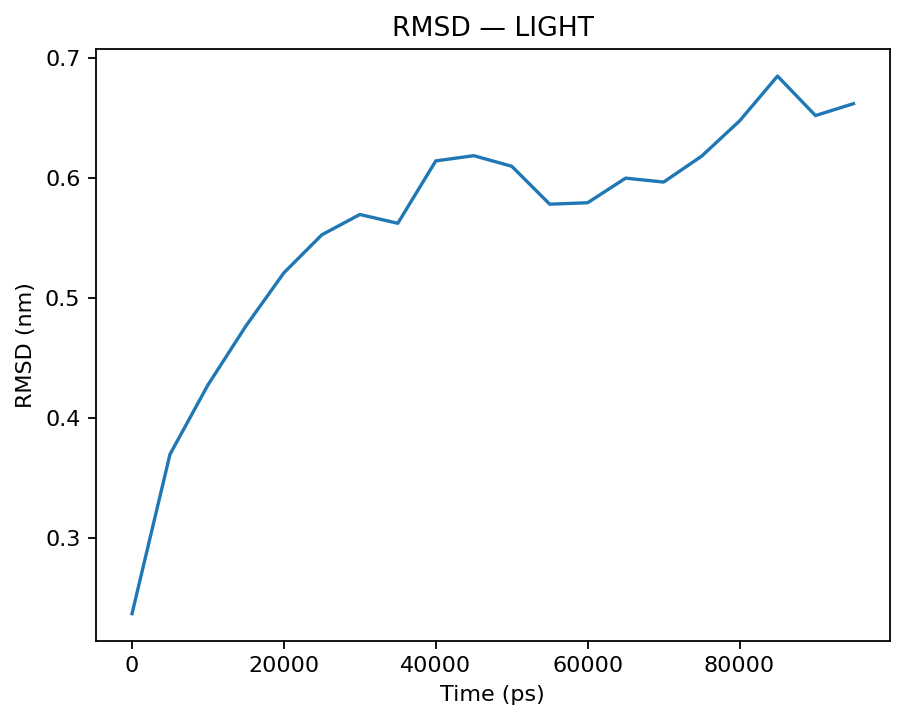



Saved summary files:
 - /kaggle/working/bcma_outputs/validate/validation_summary.md
 - /kaggle/working/bcma_outputs/validate/validation_summary.html


In [57]:
# === Final Summary & Findings (inline + files) ===
from pathlib import Path
import pandas as pd, numpy as np, json, base64, io, textwrap
from IPython.display import display, Markdown, HTML

VAL = Path("/kaggle/working/bcma_outputs/validate")
assert VAL.exists(), f"Missing folder: {VAL}"

def exists_nonempty(p: Path) -> bool:
    return p.exists() and p.is_file() and p.stat().st_size > 0

# ---------- Load artifacts ----------
delta_top5 = VAL / "deltaE_top5.csv"
rmsd_csv   = VAL / "min_md_light_rmsd.csv"
contacts   = VAL / "contacts.csv"
seq_csv    = VAL / "sequence_report.csv"
topk_csv   = VAL / "topk_light_summary.csv"
best_cx    = VAL / "best_complex.pdb"
best_r     = VAL / "best_receptor.pdb"
best_b     = VAL / "best_binder.pdb"
rmsd_png   = VAL / "min_md_light_rmsd.png"

df_delta = pd.read_csv(delta_top5) if exists_nonempty(delta_top5) else pd.DataFrame()
df_rmsd  = pd.read_csv(rmsd_csv)   if exists_nonempty(rmsd_csv)   else pd.DataFrame()
df_ct    = pd.read_csv(contacts)   if exists_nonempty(contacts)   else pd.DataFrame()
df_seq   = pd.read_csv(seq_csv)    if exists_nonempty(seq_csv)    else pd.DataFrame()
df_topk  = pd.read_csv(topk_csv)   if exists_nonempty(topk_csv)   else pd.DataFrame()

# Normalize ΔE column naming
if not df_delta.empty:
    cols_lower = {c: c.lower() for c in df_delta.columns}
    df_delta.rename(columns=cols_lower, inplace=True)
    if "deltae_kj" in df_delta.columns and "deltae_kj" not in df_delta.columns:
        df_delta.rename(columns={"deltae_kj": "deltae_kj"}, inplace=True)
    # unify to deltaE_kJ
    if "deltae_kj" in df_delta.columns and "deltaE_kJ" not in df_delta.columns:
        df_delta.rename(columns={"deltae_kj": "deltaE_kJ"}, inplace=True)
    if "deltaE_kJ" not in df_delta.columns:
        # best-effort to find energy column
        for c in df_delta.columns:
            if c.lower().startswith("deltae"):
                df_delta.rename(columns={c:"deltaE_kJ"}, inplace=True)
                break
    # sort if possible
    with pd.option_context('mode.use_inf_as_na', True):
        if "deltaE_kJ" in df_delta.columns:
            df_delta["deltaE_kJ"] = pd.to_numeric(df_delta["deltaE_kJ"], errors="coerce")
            df_delta = df_delta.sort_values("deltaE_kJ", ascending=True, na_position="last")

# ---------- Compute quick stats ----------
summary = {}

# ΔE (energy proxy)
if not df_delta.empty and "deltaE_kJ" in df_delta.columns:
    summary["n_candidates"] = int(len(df_delta))
    summary["best_deltaE_kJ"] = float(df_delta["deltaE_kJ"].iloc[0]) if pd.notna(df_delta["deltaE_kJ"].iloc[0]) else None
    # optional extras if present
    for col in ["E_complex_kJ","E_receptor_kJ","E_binder_kJ","seq_id","seq","complex_pdb","receptor_pdb","binder_pdb"]:
        if col in df_delta.columns:
            summary[col] = df_delta.iloc[0].get(col, None)
else:
    summary["n_candidates"] = 0

# RMSD (light MD)
if not df_rmsd.empty:
    # accept either nm or Å schema
    if "rmsd_nm" in df_rmsd.columns:
        rmsd_nm = pd.to_numeric(df_rmsd["rmsd_nm"], errors="coerce")
        summary["rmsd_mean_nm"] = float(np.nanmean(rmsd_nm))
        tail = rmsd_nm.tail(max(1, len(rmsd_nm)//5))
        summary["rmsd_tail_mean_nm"] = float(np.nanmean(tail))
    elif "rmsd_A" in df_rmsd.columns:
        rmsd_A = pd.to_numeric(df_rmsd["rmsd_A"], errors="coerce")
        summary["rmsd_mean_A"] = float(np.nanmean(rmsd_A))
        tail = rmsd_A.tail(max(1, len(rmsd_A)//5))
        summary["rmsd_tail_mean_A"] = float(np.nanmean(tail))
    summary["frames"] = int(len(df_rmsd))

# Contacts
if not df_ct.empty and {"chain_i","chain_j","contacts"} <= set(df_ct.columns):
    summary["contacts_total"] = int(pd.to_numeric(df_ct["contacts"], errors="coerce").sum())
    summary["contacts_pairs"] = int(df_ct.shape[0])

# Sequence
if not df_seq.empty and {"chain","length"}.issubset(df_seq.columns):
    summary["chains"] = int(len(df_seq))
    try:
        summary["seq_total_len"] = int(pd.to_numeric(df_seq["length"], errors="coerce").sum())
    except Exception:
        pass

# Top-K
if not df_topk.empty:
    # normalize deltaE name
    cols_lower = {c: c.lower() for c in df_topk.columns}
    df_topk.rename(columns=cols_lower, inplace=True)
    if "deltae_kj" in df_topk.columns and "deltaE_kJ" not in df_topk.columns:
        df_topk.rename(columns={"deltae_kj":"deltaE_kJ"}, inplace=True)
    summary["topk_rows"] = int(len(df_topk))

# ---------- Build Markdown ----------
lines = []
lines.append("# Validation Summary (NB1 ➜ NB2)")
lines.append("")
lines.append("## Artifacts")
for p in [("best_complex.pdb", best_cx), ("best_receptor.pdb", best_r), ("best_binder.pdb", best_b),
          ("deltaE_top5.csv", delta_top5), ("min_md_light_rmsd.csv", rmsd_csv), ("contacts.csv", contacts),
          ("sequence_report.csv", seq_csv), ("topk_light_summary.csv", topk_csv)]:
    ok = "✅" if exists_nonempty(p[1]) else "❌"
    size = (p[1].stat().st_size if p[1].exists() else "-")
    lines.append(f"- {ok} **{p[0]}** ({size})")

lines.append("")
lines.append("## Key Findings")

# ΔE
if summary.get("n_candidates",0) > 0:
    best_dE = summary.get("best_deltaE_kJ", None)
    if best_dE is not None:
        lines.append(f"- **ΔE (best)**: `{best_dE:.2f} kJ/mol` (more negative ≈ more favorable)")
    else:
        lines.append("- **ΔE (best)**: _not available (NaN)_")
    lines.append(f"- **Candidates evaluated**: `{summary['n_candidates']}`")
else:
    lines.append("- **ΔE**: No candidate table available.")

# RMSD
if "rmsd_mean_nm" in summary or "rmsd_mean_A" in summary:
    if "rmsd_mean_nm" in summary:
        lines.append(f"- **RMSD (mean)**: `{summary['rmsd_mean_nm']:.3f} nm`")
        lines.append(f"- **RMSD (tail mean)**: `{summary['rmsd_tail_mean_nm']:.3f} nm`")
    else:
        lines.append(f"- **RMSD (mean)**: `{summary['rmsd_mean_A']:.2f} Å`")
        lines.append(f"- **RMSD (tail mean)**: `{summary['rmsd_tail_mean_A']:.2f} Å`")
    lines.append(f"- **Frames**: `{summary.get('frames','-')}`")
else:
    lines.append("- **RMSD**: No trajectory statistics available.")

# Contacts
if "contacts_total" in summary:
    lines.append(f"- **Interface contacts**: `{summary['contacts_total']}` across `{summary['contacts_pairs']}` chain pairs")
else:
    lines.append("- **Contacts**: Not computed or single-chain complex.")

# Sequence
if "chains" in summary:
    lines.append(f"- **Chains detected**: `{summary['chains']}`; **Total residues (sum)**: `{summary.get('seq_total_len','-')}`")
else:
    lines.append("- **Sequence**: No sequence table available.")

# Top-K
if "topk_rows" in summary:
    lines.append(f"- **Top-K LIGHT MD rows**: `{summary['topk_rows']}` (see `topk_light_summary.csv`)")

lines.append("")
lines.append("## Tables")
if not df_delta.empty:
    lines.append("**ΔE Top-5 (preview)**")
    display(df_delta.head(5))
if not df_rmsd.empty:
    lines.append("**RMSD (head)**")
    display(df_rmsd.head())
if not df_ct.empty:
    lines.append("**Contacts**")
    display(df_ct)
if not df_seq.empty:
    lines.append("**Sequence**")
    display(df_seq)
if not df_topk.empty:
    lines.append("**Top-K LIGHT Summary**")
    display(df_topk)

# Inline RMSD PNG if present
def img_md(path: Path) -> str:
    if not exists_nonempty(path): return ""
    b64 = base64.b64encode(path.read_bytes()).decode("ascii")
    return f"\n![{path.name}](data:image/png;base64,{b64})\n"

if exists_nonempty(rmsd_png):
    lines.append("")
    lines.append("## RMSD Plot (LIGHT MD)")
    lines.append(img_md(rmsd_png))

md_text = "\n".join(lines)

# ---------- Save Markdown and HTML ----------
summary_md = VAL / "validation_summary.md"
summary_html = VAL / "validation_summary.html"

summary_md.write_text(md_text, encoding="utf-8")

# Simple HTML wrapper
html = f"""
<html>
<head><meta charset="utf-8"><title>BCMA Validation Summary</title></head>
<body style="font-family:system-ui,Segoe UI,Arial,sans-serif; line-height:1.5; max-width:960px; margin:2rem auto;">
{Markdown(md_text).data}
</body>
</html>
"""
summary_html.write_text(html, encoding="utf-8")

# ---------- Show inline ----------
display(Markdown(md_text))
print("\nSaved summary files:")
print(" -", summary_md)
print(" -", summary_html)
